In [ ]:
# @title
import pandas as pd
from google.colab import files
import io
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# @title
# Upload the CSV file
uploaded = files.upload()

df = None # Initialize df to None

# Assuming the user uploads only one file
if uploaded:
    for filename in uploaded.keys():
        print(f'User uploaded file "{filename}"')
        try:
            # Try reading with default comma delimiter first, then with semicolon if it fails
            try:
                df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))
            except pd.errors.ParserError:
                print("Attempting to read with semicolon delimiter...")
                df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')), sep=';')

            print("DataFrame loaded successfully. Here's a preview:")
            display(df.sample(3))
        except Exception as e:
            print(f"Error loading CSV: {e}")
        break # Process only the first file if multiple are uploaded
else:
    print("No file was uploaded. Please upload a CSV file.")

Saving Employee-Attrition.csv to Employee-Attrition.csv
User uploaded file "Employee-Attrition.csv"
DataFrame loaded successfully. Here's a preview:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1033,31,Yes,Travel_Frequently,1445,Research & Development,1,5,Life Sciences,1,1459,...,1,80,0,10,2,3,10,8,4,7
561,52,No,Travel_Rarely,621,Sales,3,4,Marketing,1,776,...,1,80,0,34,3,4,34,6,1,16
802,33,No,Travel_Frequently,970,Sales,7,3,Life Sciences,1,1114,...,3,80,1,4,3,3,3,2,0,2


In [ ]:
# @title
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# @title
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# @title
duplicate_employee_numbers = df[df['EmployeeNumber'].duplicated(keep=False)]

if not duplicate_employee_numbers.empty:
    print(f"Found {len(duplicate_employee_numbers)} rows with duplicate 'EmployeeNumber' values:")
    print(duplicate_employee_numbers[['EmployeeNumber']].sort_values(by='EmployeeNumber'))
else:
    print("No duplicate 'EmployeeNumber' values found.")

No duplicate 'EmployeeNumber' values found.


In [ ]:
# @title
def plot_distribution_and_describe(dataframe, column_name):
    """
    Plots the distribution of a given column in a DataFrame and displays its descriptive statistics.
    Handles both numerical (histplot) and categorical (countplot) columns.
    Also calculates and prints the correlation with 'Attrition' if the column is numerical.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to analyze.
    """
    if column_name not in dataframe.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    print(f"--- Analysis for column: {column_name} ---")

    # Display descriptive statistics
    print("\nDescriptive Statistics:")
    display(dataframe[column_name].describe())

    # Convert 'Attrition' to numerical for correlation calculation
    attrition_numeric = dataframe['Attrition'].map({'Yes': 1, 'No': 0})

    # Plot distribution based on column type and calculate correlation
    plt.figure(figsize=(8, 5))
    if pd.api.types.is_numeric_dtype(dataframe[column_name]):
        sns.histplot(dataframe[column_name], kde=True, color='#45a778')
        plt.title(f'Distribution of {column_name}')
        plt.xlabel(column_name)
        plt.ylabel('Frequency')

        # Calculate and print correlation with Attrition
        correlation = dataframe[column_name].corr(attrition_numeric)
        print(f"\nCorrelation with Attrition (Yes=1, No=0): {correlation:.4f}")

    elif isinstance(dataframe[column_name].dtype, pd.CategoricalDtype) or dataframe[column_name].dtype == 'object':
        sns.countplot(x=column_name, data=dataframe, palette='viridis', hue=column_name, legend=False)
        plt.title(f'Distribution of {column_name}')
        plt.xlabel(column_name)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        print("\nCorrelation with Attrition is not directly applicable for categorical columns.")
    else:
        print(f"Cannot plot distribution for column '{column_name}' of type: {dataframe[column_name].dtype}")
        plt.close() # Close the empty figure
        return

    plt.show()

def plot_attrition_by_group(dataframe, group_column):
    """
    Groups the DataFrame by a specified column and plots the ratio of 'Yes' attrition
    for each group using a seaborn bar plot.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        group_column (str): The name of the column to group by.
    """
    if group_column not in dataframe.columns:
        print(f"Error: Group column '{group_column}' not found in the DataFrame.")
        return

    # Calculate attrition rate
    attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()

    if 'Yes' in attrition_rates.columns:
        attrition_rates['Attrition_Yes_Ratio'] = attrition_rates['Yes'] * 100
        attrition_rates = attrition_rates.reset_index()

        plt.figure(figsize=(10, 6))
        sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')
        plt.title(f'Attrition Rate (%) by {group_column}')
        plt.xlabel(group_column)
        plt.ylabel('Attrition Rate (%)')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if many categories
        plt.tight_layout()
        plt.show()
    else:
        print(f"No 'Yes' attrition found in column '{group_column}'.")

def create_grouped_column(dataframe, numerical_column_name, num_groups, new_column_prefix='Group', labels=None):
    """
    Splits a numerical column into a specified number of quantile-based groups
    and adds the new categorical column to the DataFrame.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        numerical_column_name (str): The name of the numerical column to group.
        num_groups (int): The desired number of groups.
        new_column_prefix (str): Prefix for the new column name (e.g., 'Income_Group').
        labels (list, optional): A list of custom labels for the groups. If None,
                                 labels will be generated dynamically.

    Returns:
        pd.DataFrame: The DataFrame with the new grouped column.
    """
    if numerical_column_name not in dataframe.columns:
        print(f"Error: Column '{numerical_column_name}' not found in the DataFrame.")
        return dataframe

    if not pd.api.types.is_numeric_dtype(dataframe[numerical_column_name]):
        print(f"Error: Column '{numerical_column_name}' is not numerical.")
        return dataframe

    if labels is not None:
        if len(labels) != num_groups:
            print(f"Error: Number of labels ({len(labels)}) must match num_groups ({num_groups}).")
            return dataframe
    else:
        # Generate labels for the groups dynamically if not provided
        labels = [f'{new_column_prefix}_{i+1}' for i in range(num_groups)]

    # Use qcut to split the numerical column into equal-sized quantiles
    new_column_name = f'{new_column_prefix}s'
    dataframe[new_column_name] = pd.qcut(dataframe[numerical_column_name],
                                         q=num_groups,
                                         labels=labels,
                                         duplicates='drop') # 'drop' handles cases with identical quantile values

    print(f"New column '{new_column_name}' created with {num_groups} groups based on '{numerical_column_name}'.")
    return dataframe

In [ ]:
df_sales = df[df['Department'] == 'Sales']
df_sales.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,446.000000,446.000000,446.000000,446.000000,446.0,446.000000,446.000000,446.000000,446.000000,446.000000,...,446.000000,446.0,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,36.542601,800.275785,9.365471,2.934978,1.0,1038.946188,2.679372,65.520179,2.701794,2.255605,...,2.695067,80.0,0.773543,11.105381,2.847534,2.816143,7.284753,4.486547,2.354260,4.271300
std,9.032611,402.797474,8.086808,1.031105,0.0,599.722536,1.084259,20.354461,0.705259,0.927557,...,1.114288,0.0,0.840182,7.597168,1.244884,0.675284,6.234885,3.660116,3.353357,3.643117
min,18.000000,107.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,472.000000,2.000000,2.000000,1.0,513.750000,2.000000,48.000000,2.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,35.000000,770.500000,7.000000,3.000000,1.0,991.000000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,42.000000,1171.000000,13.000000,4.000000,1.0,1566.500000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,14.750000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2065.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,38.000000,6.000000,4.000000,37.000000,17.000000,15.000000,17.000000


--- Analysis for column: Age ---

Descriptive Statistics:


,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000



Correlation with Attrition (Yes=1, No=0): -0.1592


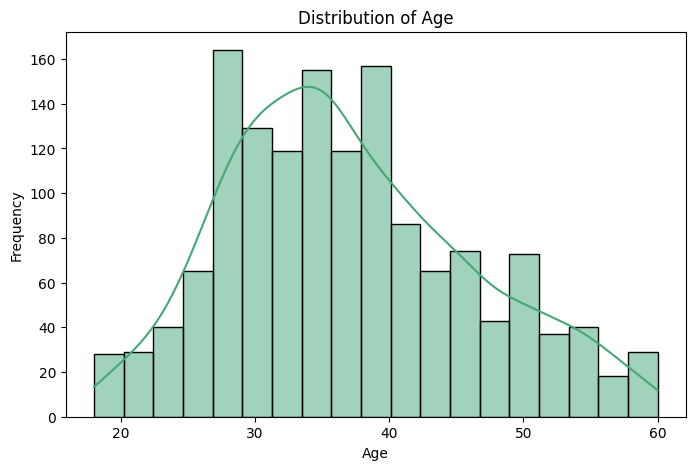

New column 'Ages' created with 4 groups based on 'Age'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


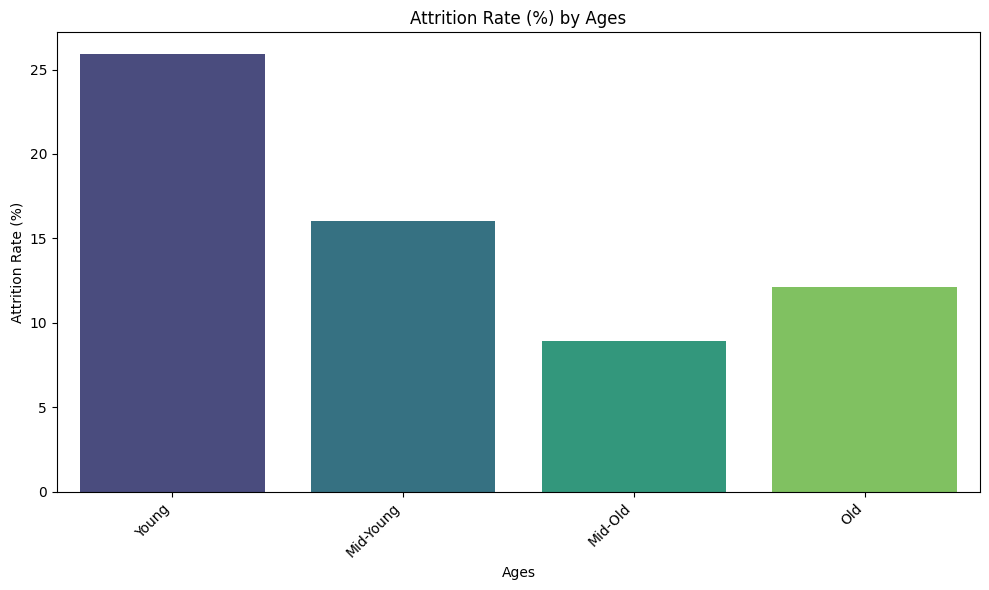

In [ ]:

plot_distribution_and_describe(df, 'Age')
# plot_distribution_and_describe(df, 'Ages')
df = create_grouped_column(df, 'Age', 4, new_column_prefix='Age',labels=['Young','Mid-Young','Mid-Old','Old'])
plot_attrition_by_group(df,'Ages')

--- Analysis for column: BusinessTravel ---

Descriptive Statistics:


,BusinessTravel
count,1470
unique,3
top,Travel_Rarely
freq,1043



Correlation with Attrition is not directly applicable for categorical columns.


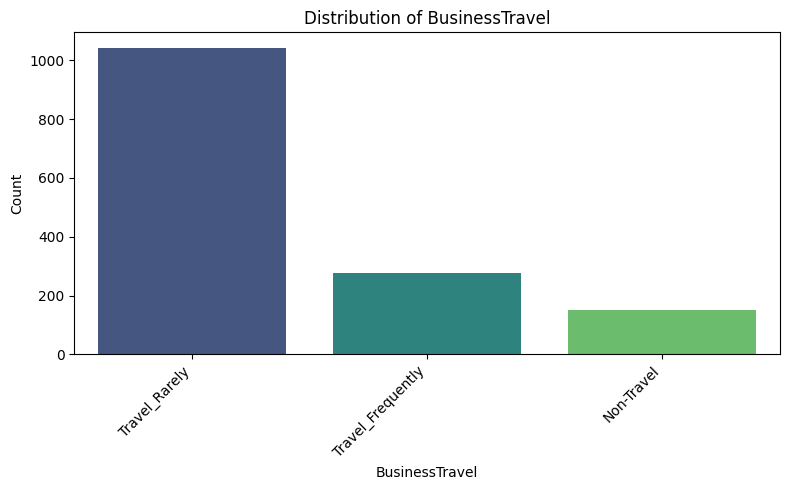

In [ ]:
plot_distribution_and_describe(df, 'BusinessTravel')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


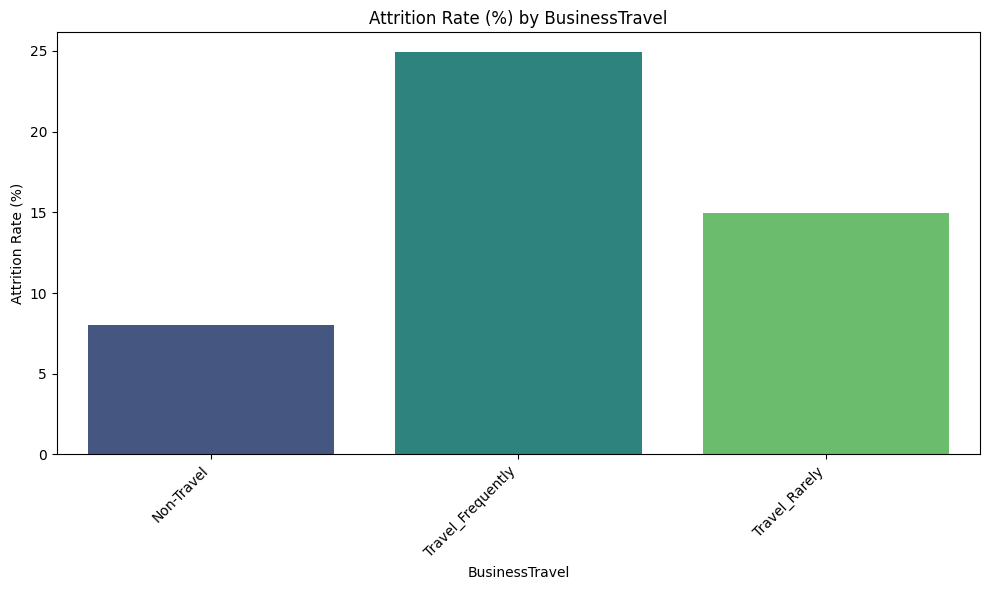

In [ ]:
plot_attrition_by_group(df,'BusinessTravel')

--- Analysis for column: DailyRate ---

Descriptive Statistics:


,DailyRate
count,1470.000000
mean,802.485714
std,403.509100
min,102.000000
25%,465.000000
50%,802.000000
75%,1157.000000
max,1499.000000



Correlation with Attrition (Yes=1, No=0): -0.0567


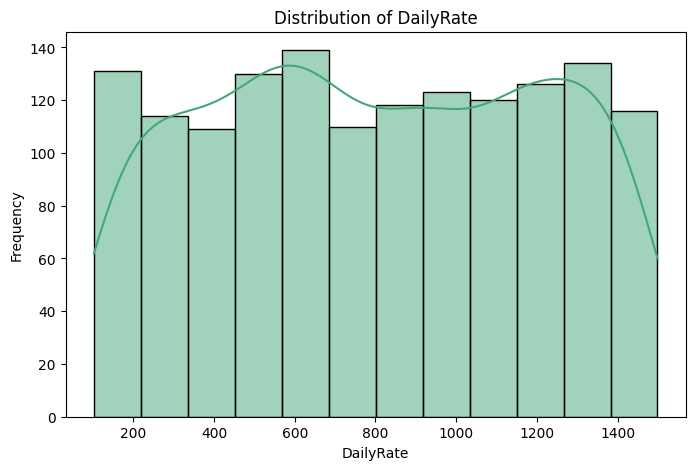

In [ ]:
plot_distribution_and_describe(df, 'DailyRate')

--- Analysis for column: HourlyRate ---

Descriptive Statistics:


,HourlyRate
count,1470.000000
mean,65.891156
std,20.329428
min,30.000000
25%,48.000000
50%,66.000000
75%,83.750000
max,100.000000



Correlation with Attrition (Yes=1, No=0): -0.0068


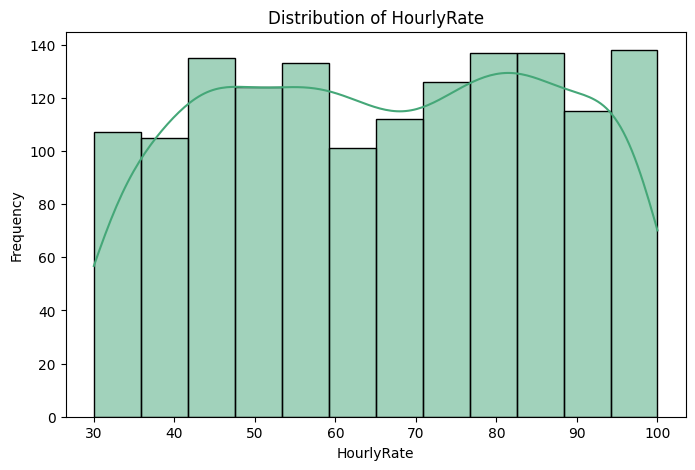

In [ ]:
plot_distribution_and_describe(df, 'HourlyRate')

--- Analysis for column: MonthlyRate ---

Descriptive Statistics:


,MonthlyRate
count,1470.000000
mean,14313.103401
std,7117.786044
min,2094.000000
25%,8047.000000
50%,14235.500000
75%,20461.500000
max,26999.000000



Correlation with Attrition (Yes=1, No=0): 0.0152


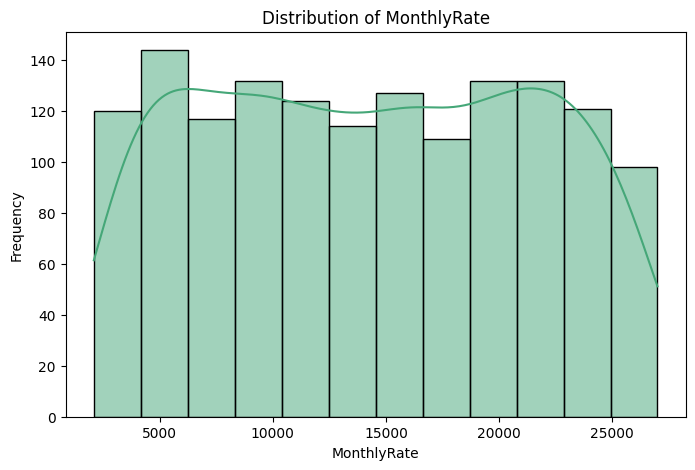

In [ ]:
plot_distribution_and_describe(df, 'MonthlyRate')

--- Analysis for column: Department ---

Descriptive Statistics:


,Department
count,1470
unique,3
top,Research & Development
freq,961



Correlation with Attrition is not directly applicable for categorical columns.


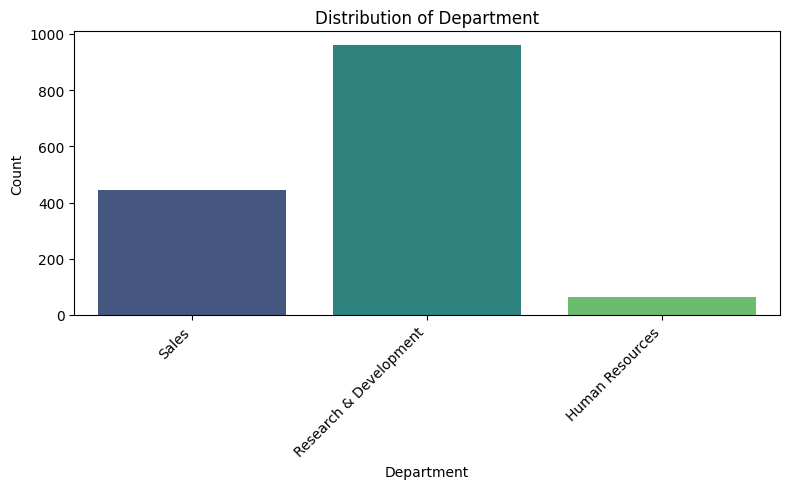

In [ ]:
plot_distribution_and_describe(df, 'Department')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


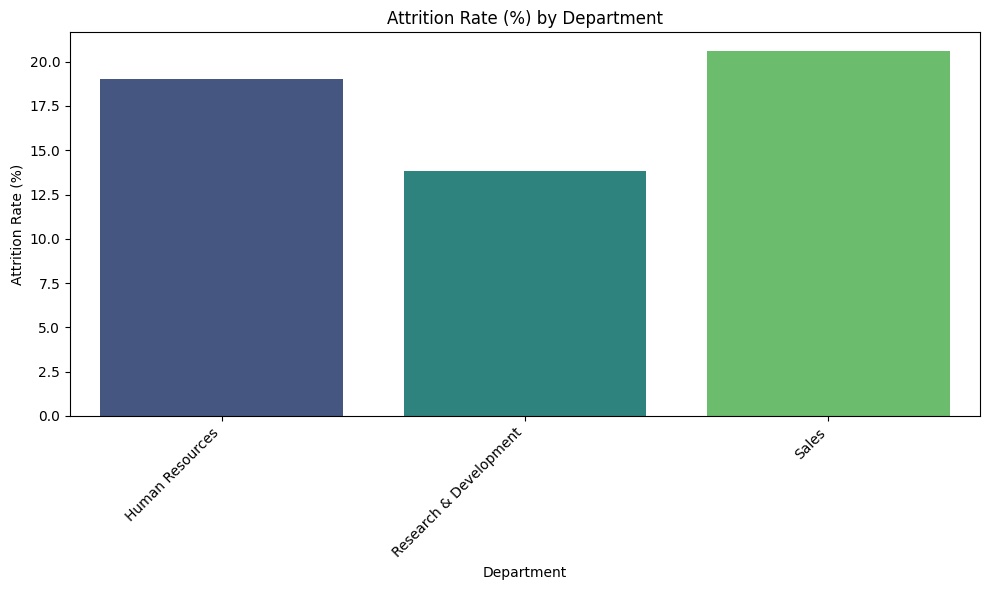

In [ ]:
plot_attrition_by_group(df,'Department')

--- Analysis for column: DistanceFromHome ---

Descriptive Statistics:


,DistanceFromHome
count,1470.000000
mean,9.192517
std,8.106864
min,1.000000
25%,2.000000
50%,7.000000
75%,14.000000
max,29.000000



Correlation with Attrition (Yes=1, No=0): 0.0779


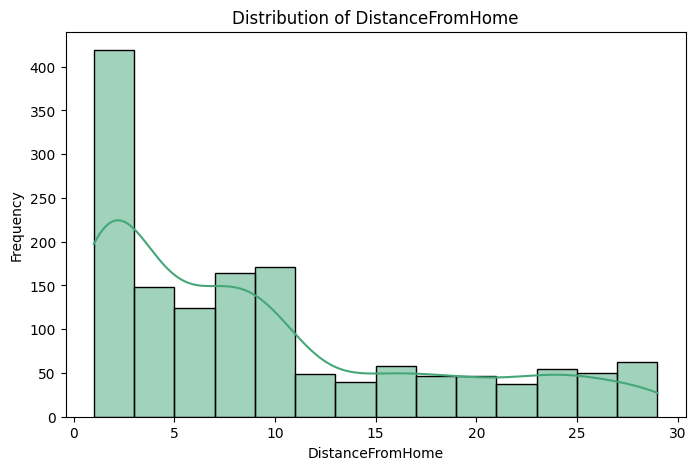

In [ ]:
plot_distribution_and_describe(df, 'DistanceFromHome')

--- Analysis for column: Education ---

Descriptive Statistics:


,Education
count,1470.000000
mean,2.912925
std,1.024165
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000



Correlation with Attrition (Yes=1, No=0): -0.0314


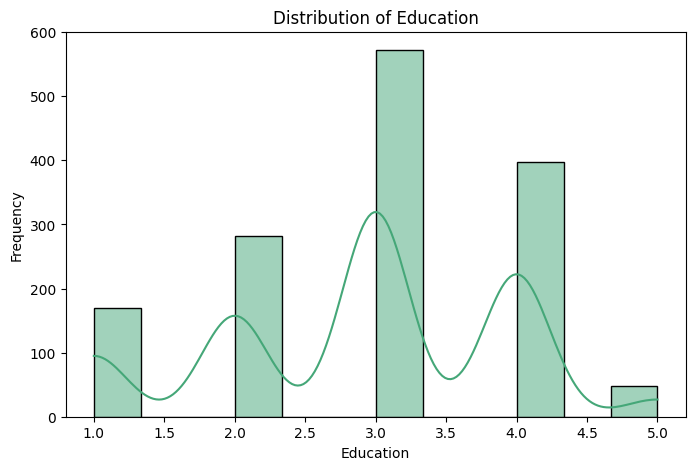

In [ ]:
plot_distribution_and_describe(df, 'Education')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


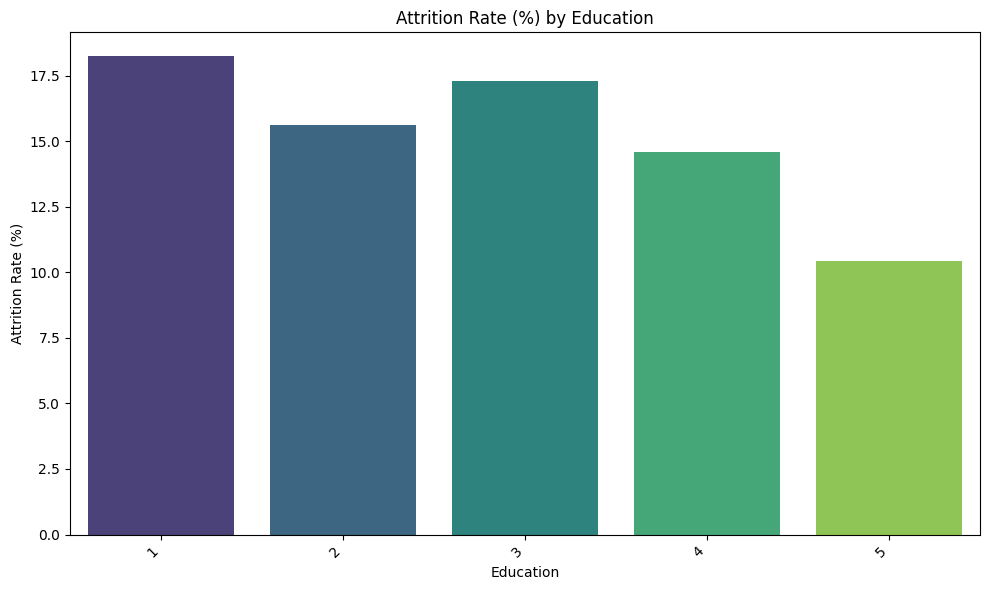

In [ ]:
plot_attrition_by_group(df, 'Education')

--- Analysis for column: EducationField ---

Descriptive Statistics:


,EducationField
count,1470
unique,6
top,Life Sciences
freq,606



Correlation with Attrition is not directly applicable for categorical columns.


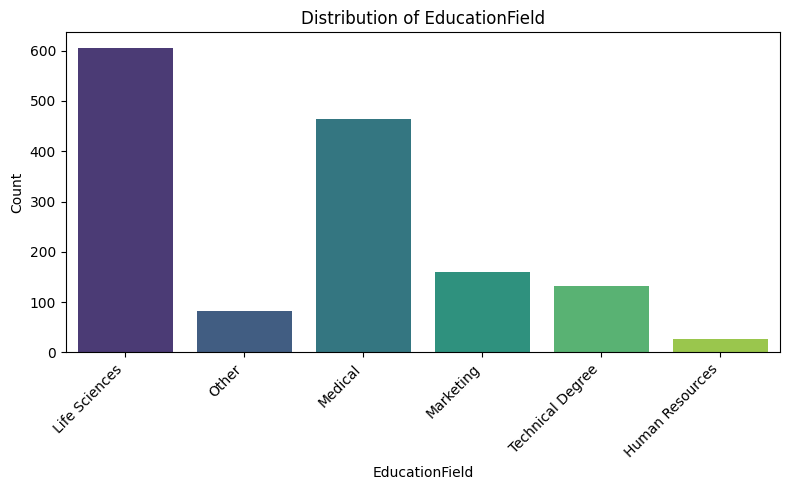

In [ ]:
plot_distribution_and_describe(df, 'EducationField')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


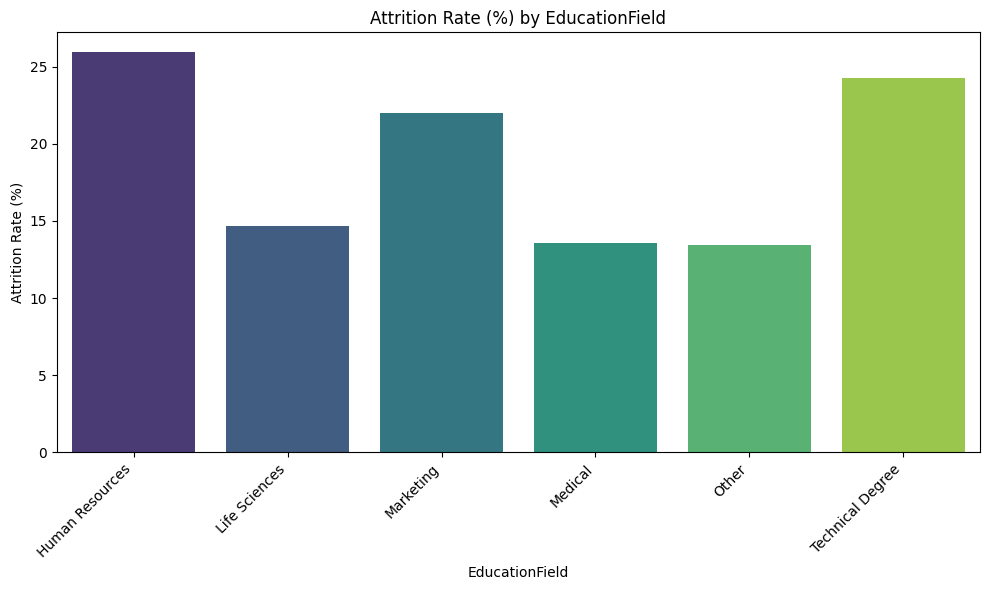

In [ ]:
plot_attrition_by_group(df,'EducationField')

--- Analysis for column: Gender ---

Descriptive Statistics:


,Gender
count,1470
unique,2
top,Male
freq,882



Correlation with Attrition is not directly applicable for categorical columns.


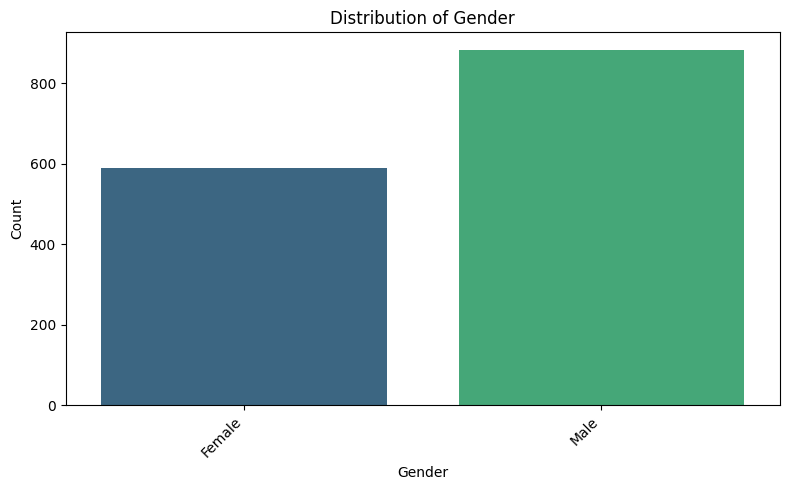

In [ ]:
plot_distribution_and_describe(df, 'Gender')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


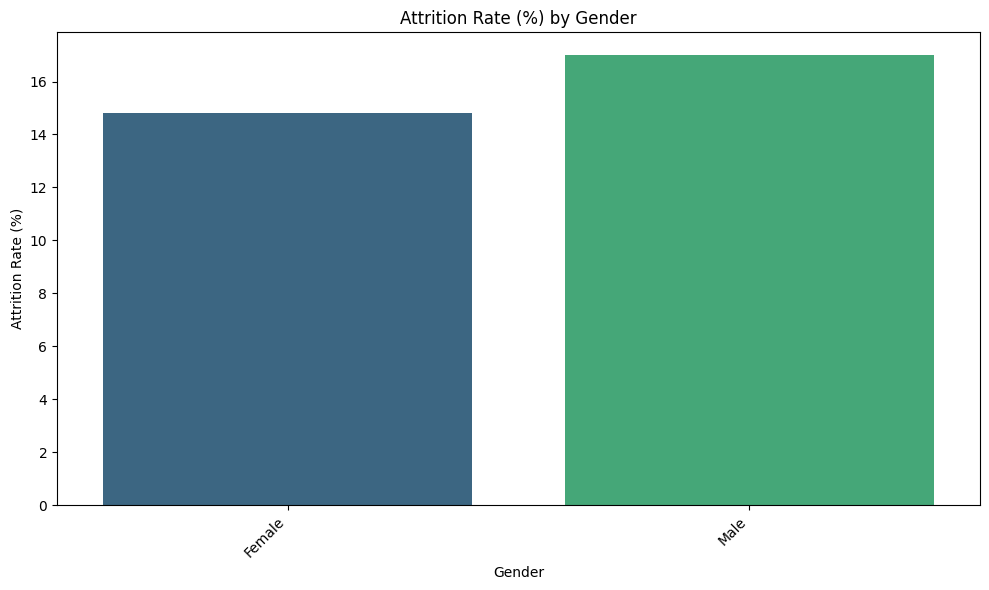

In [ ]:
plot_attrition_by_group(df,'Gender')

--- Analysis for column: JobInvolvement ---

Descriptive Statistics:


,JobInvolvement
count,1470.000000
mean,2.729932
std,0.711561
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): -0.1300


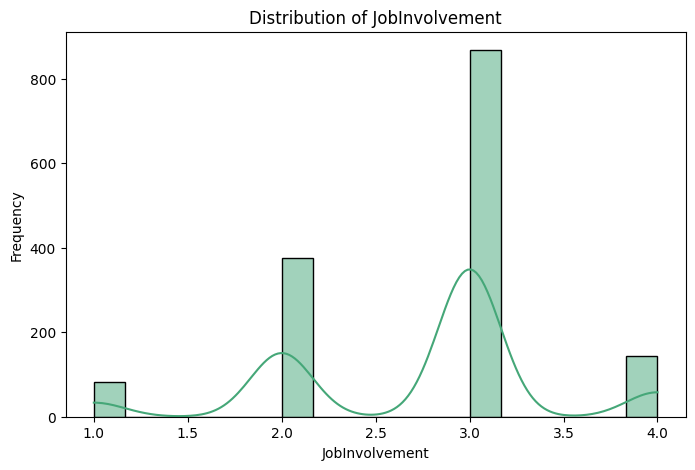

In [ ]:
plot_distribution_and_describe(df, 'JobInvolvement')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


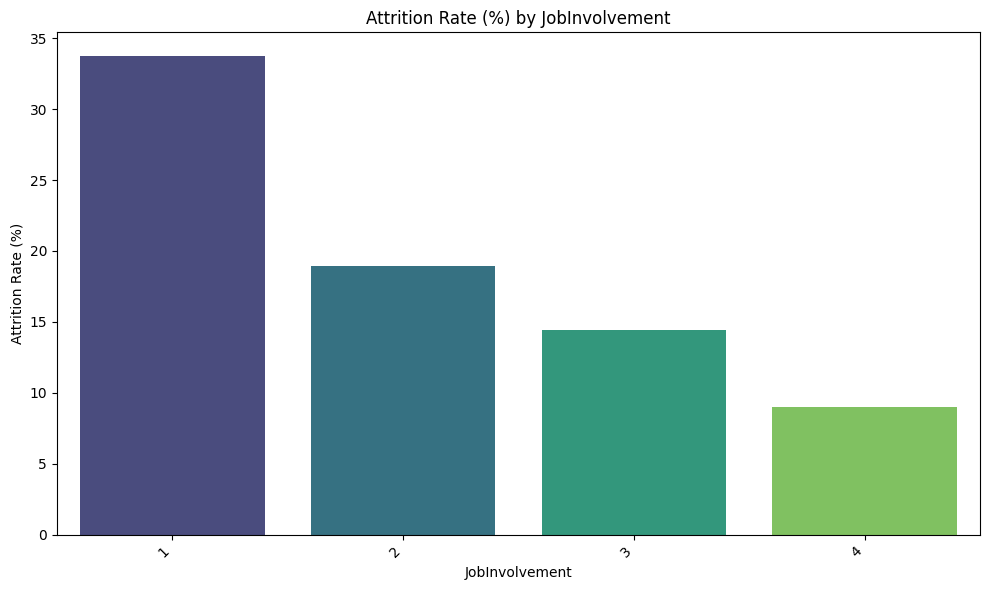

In [ ]:
plot_attrition_by_group(df,'JobInvolvement')

--- Analysis for column: JobLevel ---

Descriptive Statistics:


,JobLevel
count,1470.000000
mean,2.063946
std,1.106940
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000



Correlation with Attrition (Yes=1, No=0): -0.1691


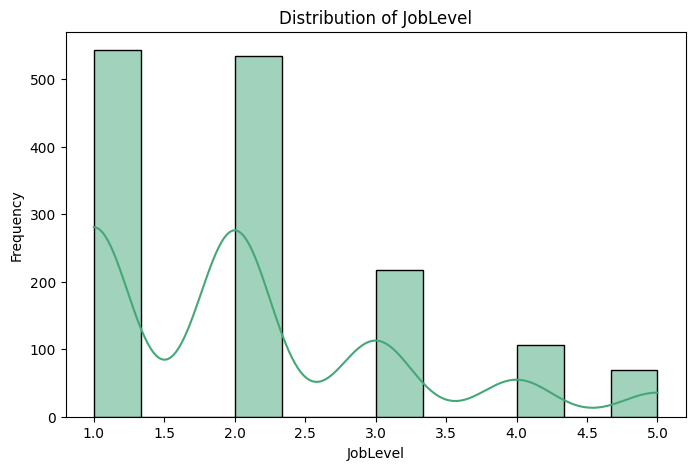

In [ ]:
plot_distribution_and_describe(df, 'JobLevel')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


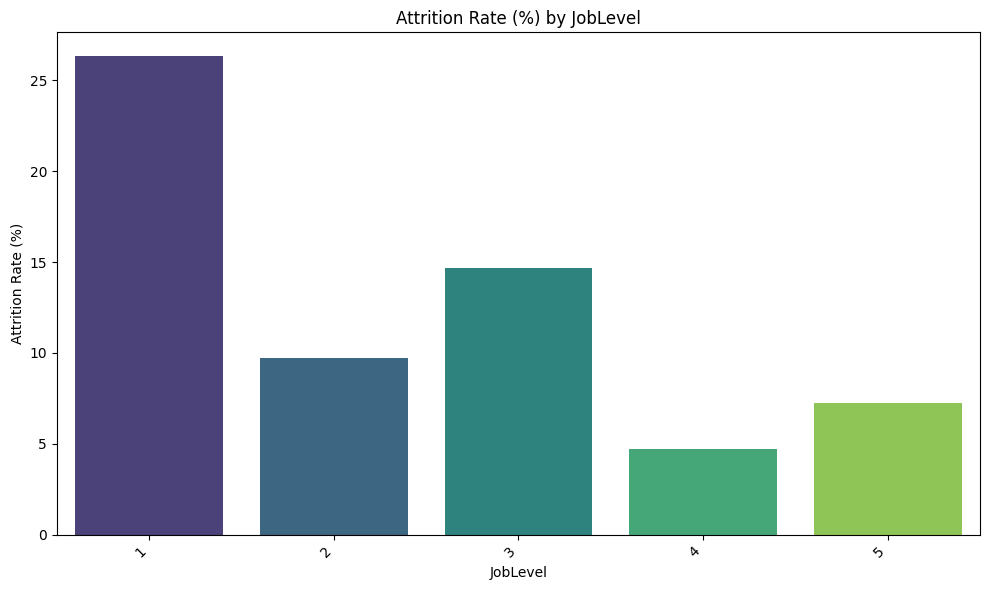

In [ ]:
plot_attrition_by_group(df,'JobLevel')

--- Analysis for column: JobRole ---

Descriptive Statistics:


,JobRole
count,1470
unique,9
top,Sales Executive
freq,326



Correlation with Attrition is not directly applicable for categorical columns.


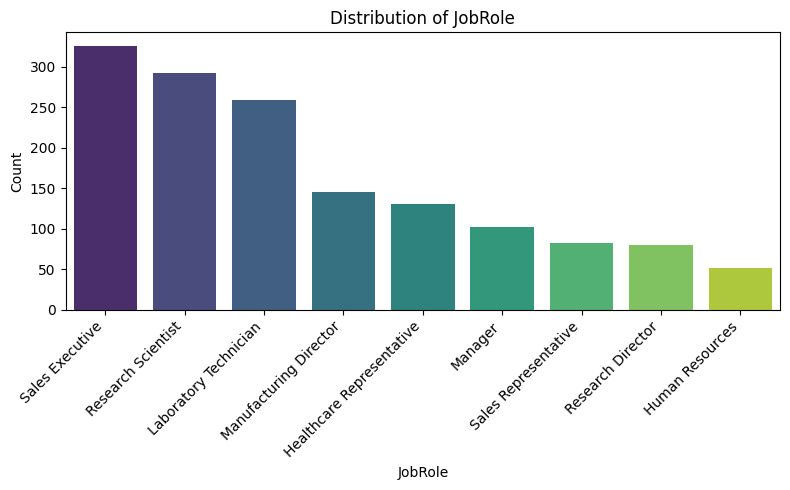

In [ ]:
plot_distribution_and_describe(df, 'JobRole')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


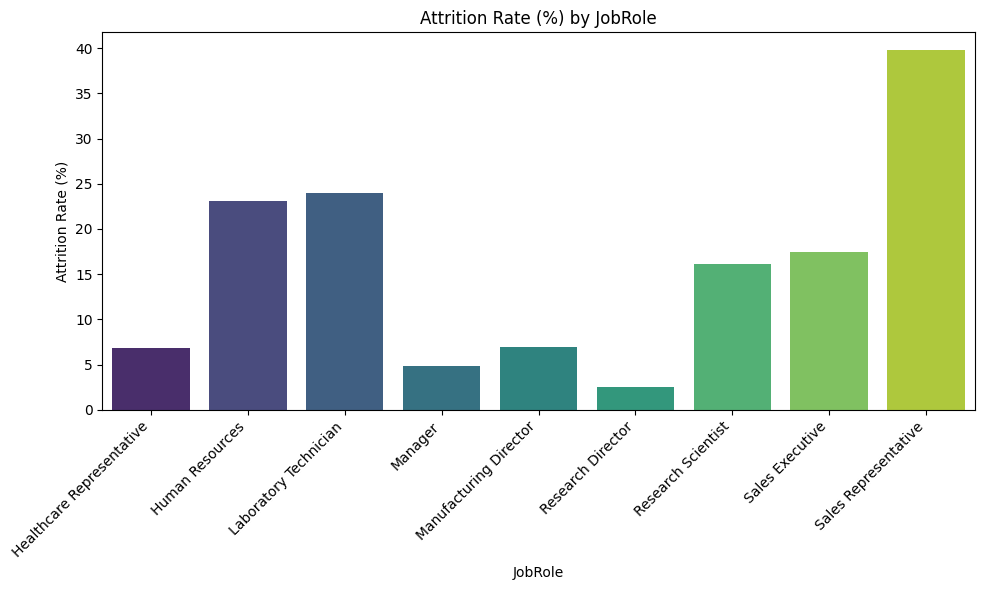

In [ ]:
plot_attrition_by_group(df,'JobRole')

--- Analysis for column: JobSatisfaction ---

Descriptive Statistics:


,JobSatisfaction
count,1470.000000
mean,2.728571
std,1.102846
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): -0.1035


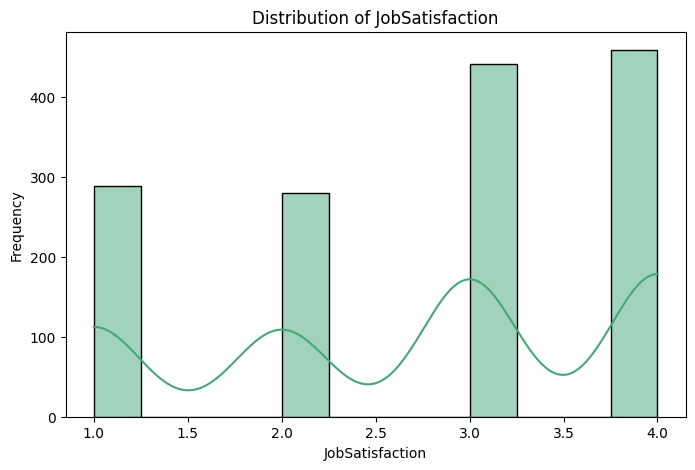

In [ ]:
plot_distribution_and_describe(df, 'JobSatisfaction')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


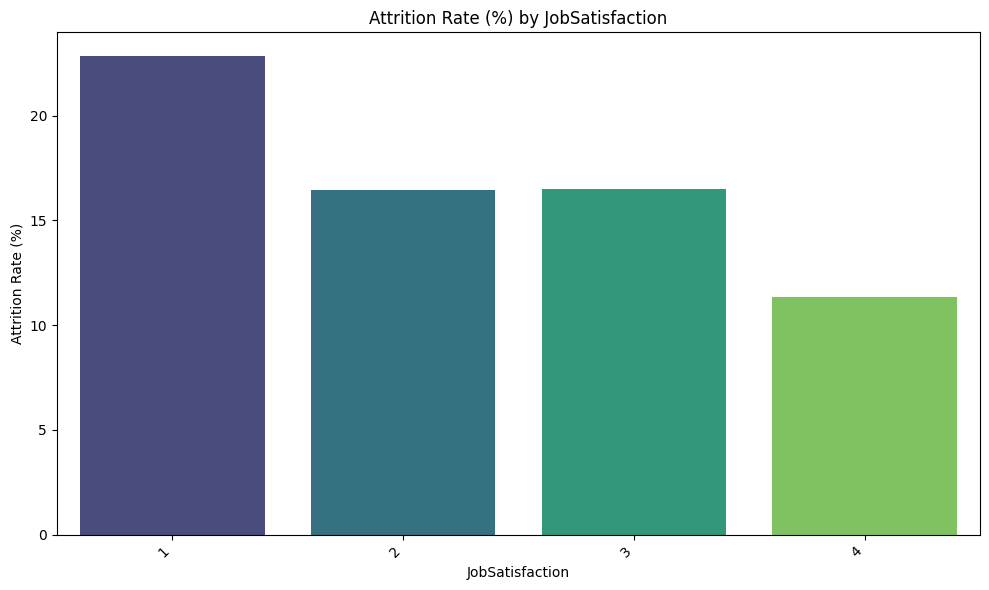

In [ ]:
plot_attrition_by_group(df,'JobSatisfaction')

--- Analysis for column: MaritalStatus ---

Descriptive Statistics:


,MaritalStatus
count,1470
unique,3
top,Married
freq,673



Correlation with Attrition is not directly applicable for categorical columns.


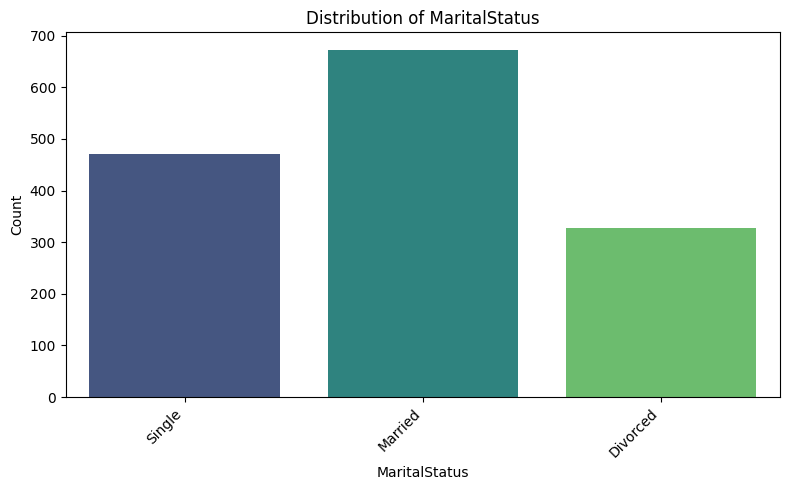

In [ ]:
plot_distribution_and_describe(df, 'MaritalStatus')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


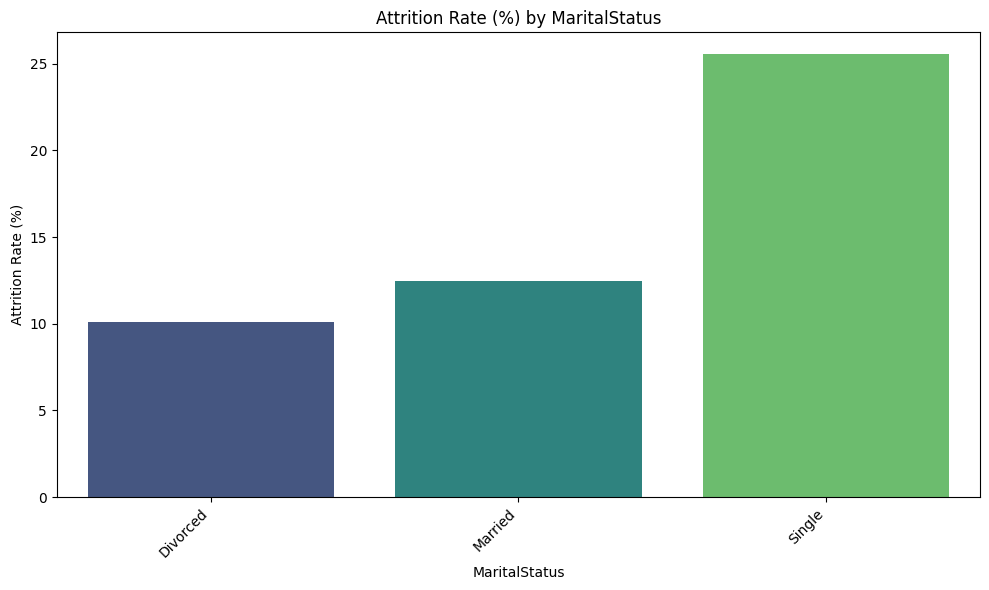

In [ ]:
plot_attrition_by_group(df,'MaritalStatus')

--- Analysis for column: MonthlyIncome ---

Descriptive Statistics:


,MonthlyIncome
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000



Correlation with Attrition (Yes=1, No=0): -0.1598


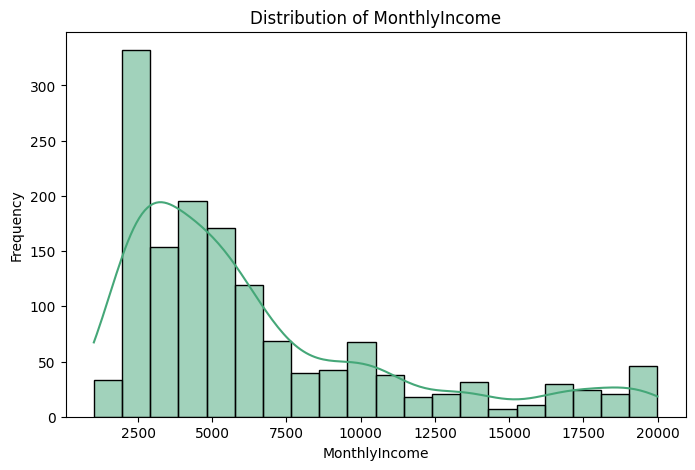

In [ ]:
plot_distribution_and_describe(df, 'MonthlyIncome')
# plot_attrition_by_group(df,'MaritalStatus')

## SEE BOTTOM

New column 'Incomes' created with 4 groups based on 'MonthlyIncome'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


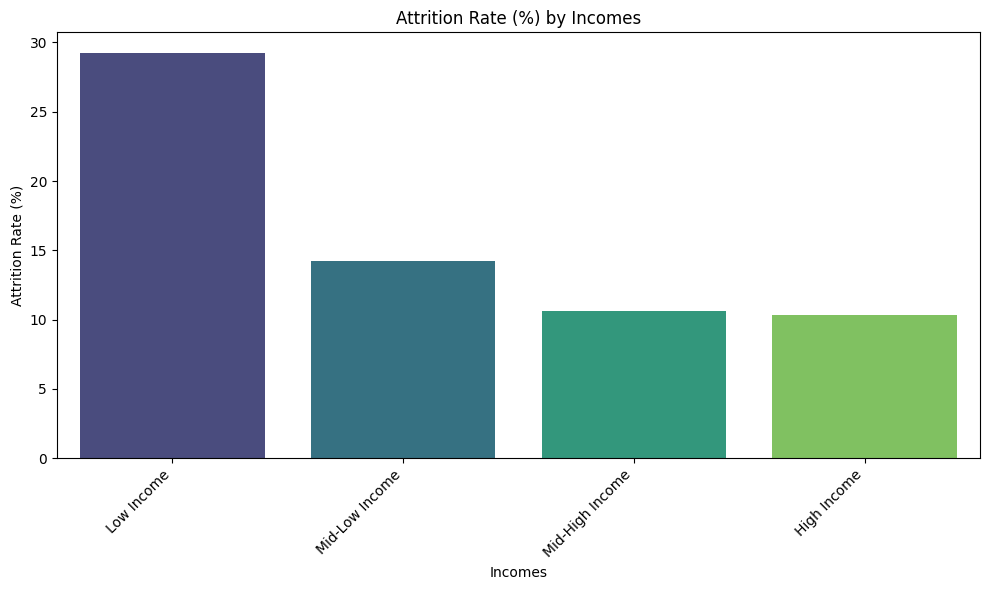

In [ ]:
df = create_grouped_column(df, 'MonthlyIncome', 4, new_column_prefix='Income', labels=['Low Income', 'Mid-Low Income', 'Mid-High Income', 'High Income'])
plot_attrition_by_group(df, 'Incomes')

--- Analysis for column: NumCompaniesWorked ---

Descriptive Statistics:


,NumCompaniesWorked
count,1470.000000
mean,2.693197
std,2.498009
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,9.000000



Correlation with Attrition (Yes=1, No=0): 0.0435


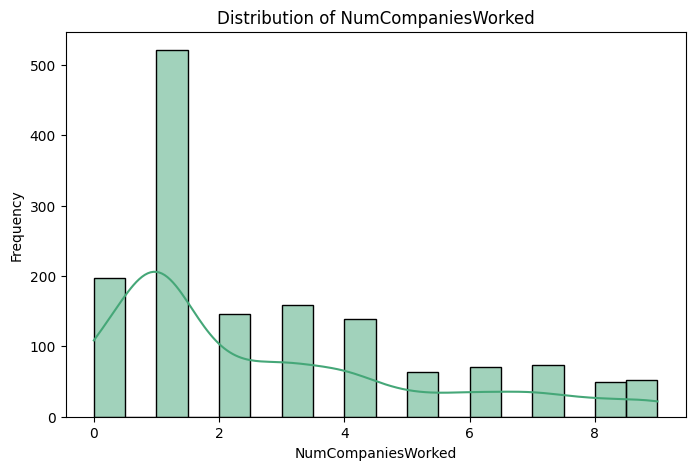

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


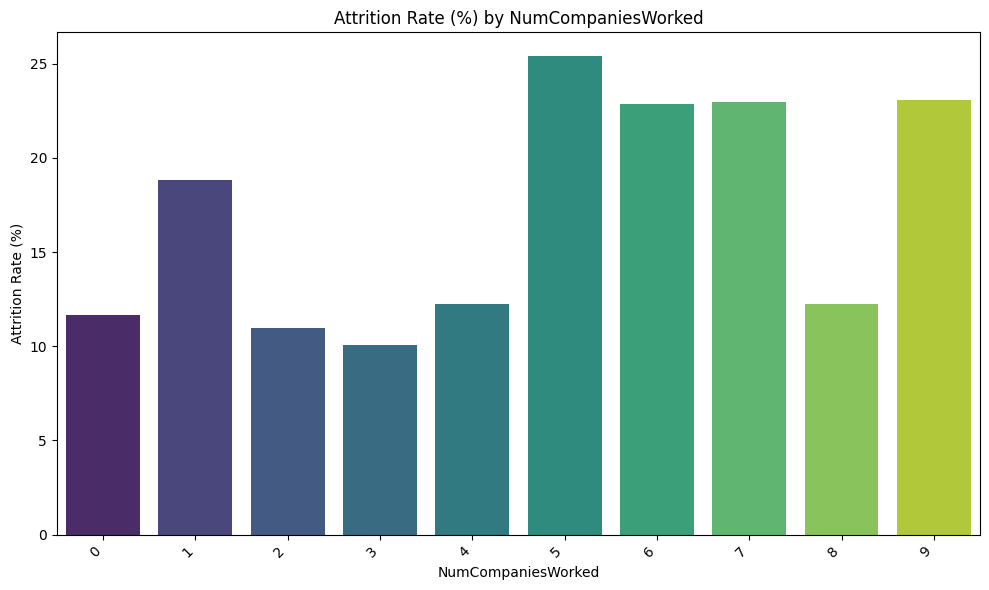

In [ ]:
plot_distribution_and_describe(df, 'NumCompaniesWorked')
# df = create_grouped_column(df, 'NumCompaniesWorked', 8, new_column_prefix='WorkedCompanie')
# # plot_distribution_and_describe(df, 'CompaniesWorked')
plot_attrition_by_group(df,'NumCompaniesWorked')


--- Analysis for column: OverTime ---

Descriptive Statistics:


,OverTime
count,1470
unique,2
top,No
freq,1054



Correlation with Attrition is not directly applicable for categorical columns.


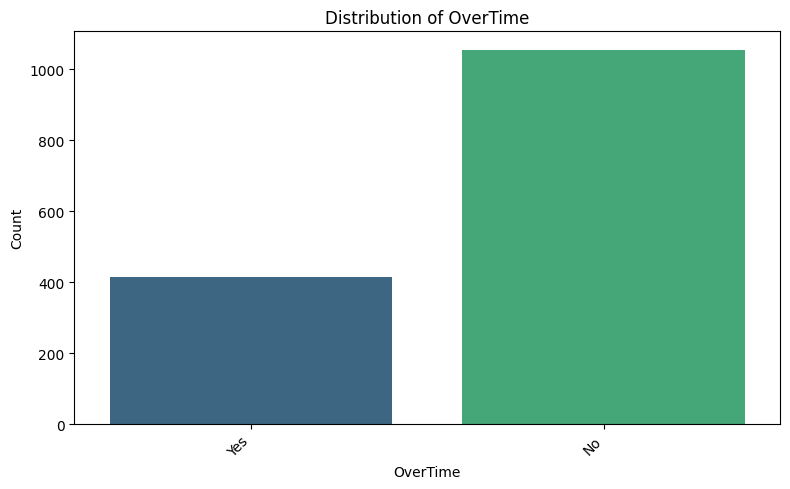

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


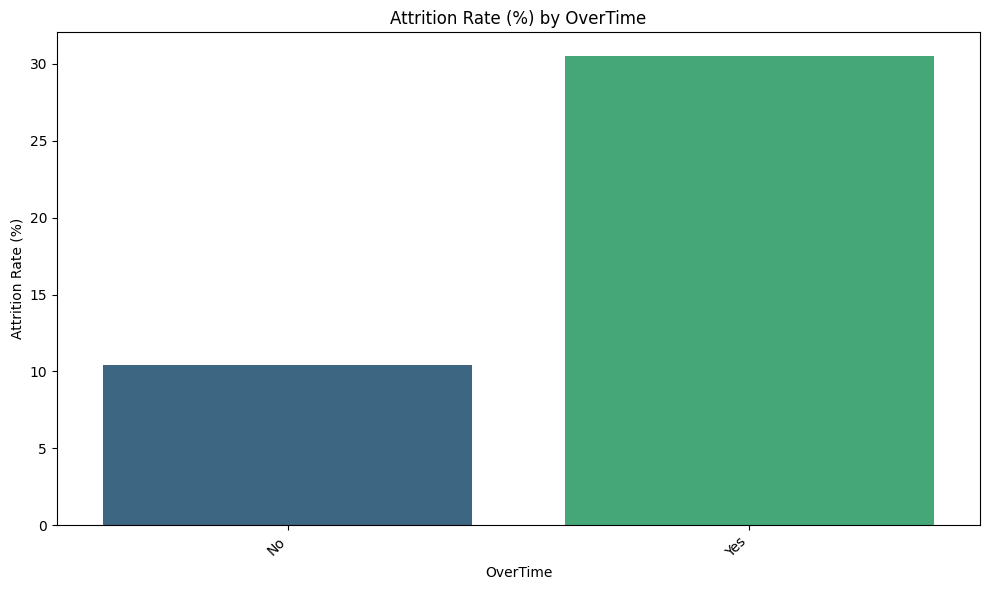

In [ ]:
plot_distribution_and_describe(df, 'OverTime')
# df = create_grouped_column(df, 'NumCompaniesWorked', 8, new_column_prefix='WorkedCompanie')
# # plot_distribution_and_describe(df, 'CompaniesWorked')
plot_attrition_by_group(df,'OverTime')

--- Analysis for column: PercentSalaryHike ---

Descriptive Statistics:


,PercentSalaryHike
count,1470.000000
mean,15.209524
std,3.659938
min,11.000000
25%,12.000000
50%,14.000000
75%,18.000000
max,25.000000



Correlation with Attrition (Yes=1, No=0): -0.0135


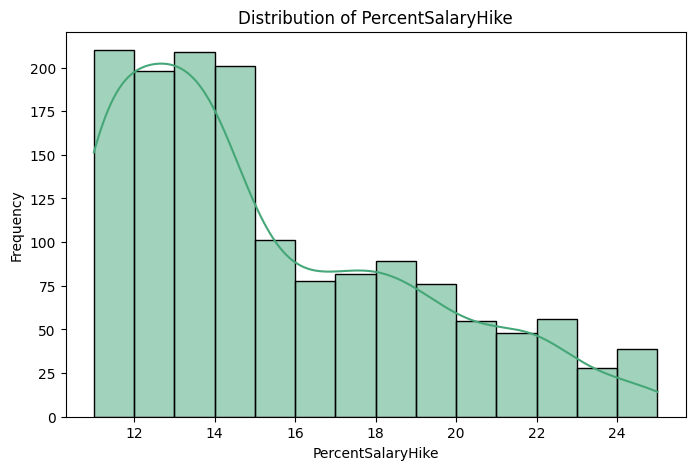

New column 'SalaryHikePercents' created with 4 groups based on 'PercentSalaryHike'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


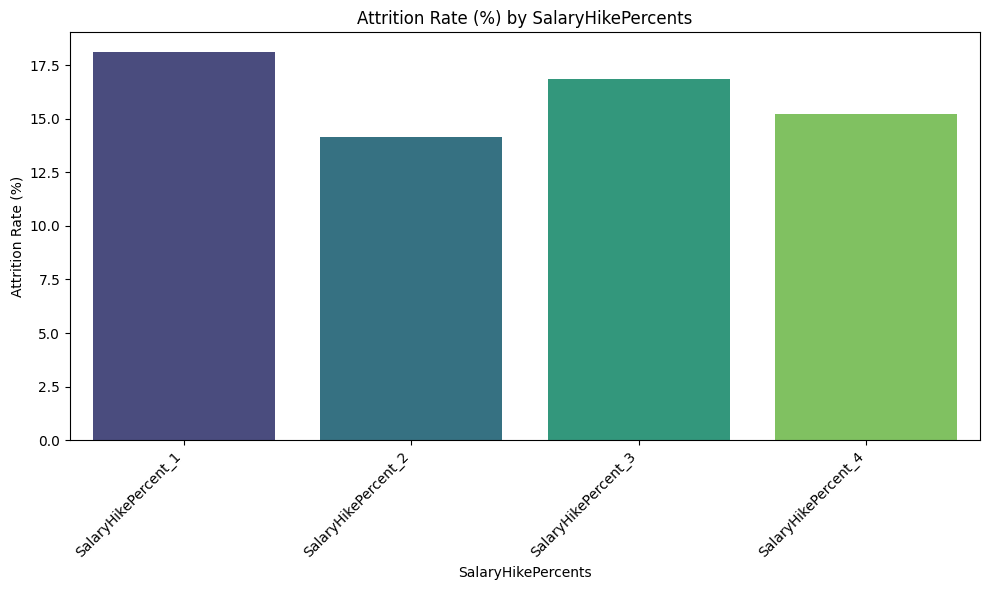

In [ ]:
plot_distribution_and_describe(df, 'PercentSalaryHike')
df = create_grouped_column(df, 'PercentSalaryHike', 4, new_column_prefix='SalaryHikePercent')
# # plot_distribution_and_describe(df, 'CompaniesWorked')
plot_attrition_by_group(df,'SalaryHikePercents')

--- Analysis for column: PerformanceRating ---

Descriptive Statistics:


,PerformanceRating
count,1470.000000
mean,3.153741
std,0.360824
min,3.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): 0.0029


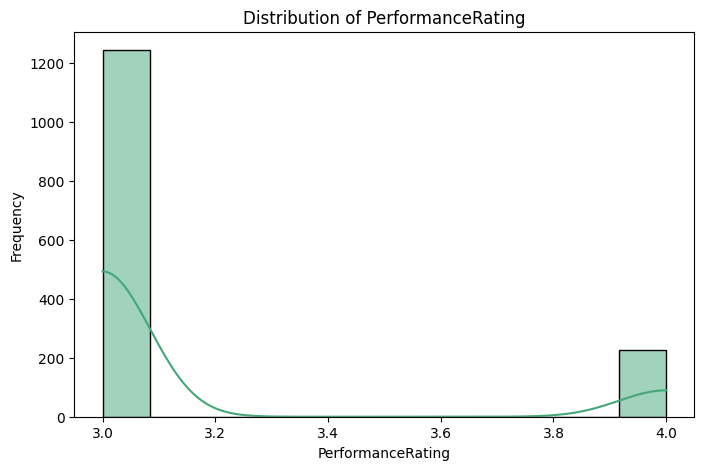

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


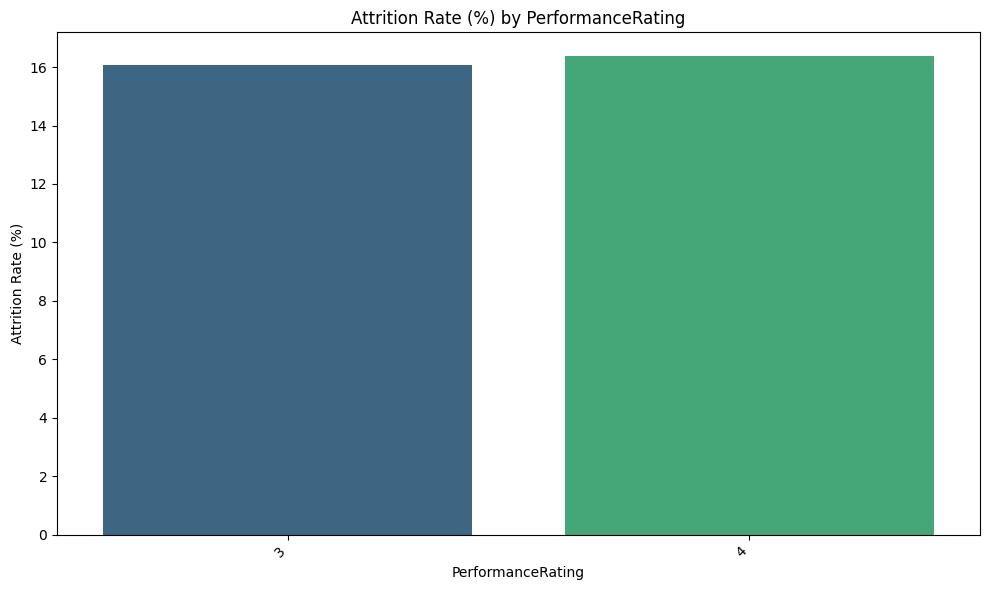

In [ ]:
plot_distribution_and_describe(df, 'PerformanceRating')
# df = create_grouped_column(df, 'PercentSalaryHike', 3, new_column_prefix='SalaryHikePercent')
plot_attrition_by_group(df,'PerformanceRating')

--- Analysis for column: RelationshipSatisfaction ---

Descriptive Statistics:


,RelationshipSatisfaction
count,1470.000000
mean,2.712245
std,1.081209
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): -0.0459


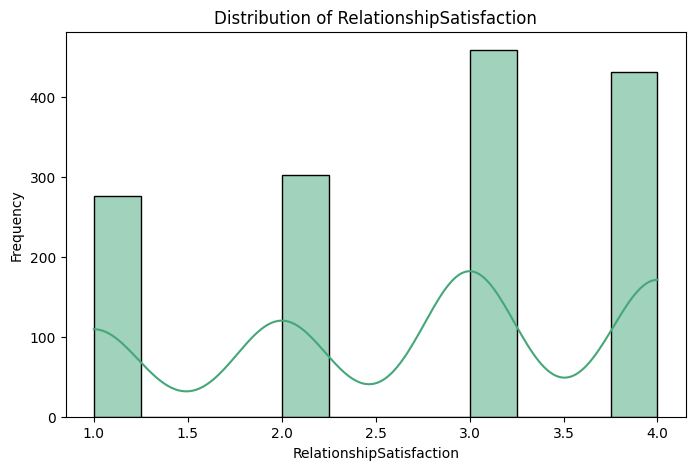

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


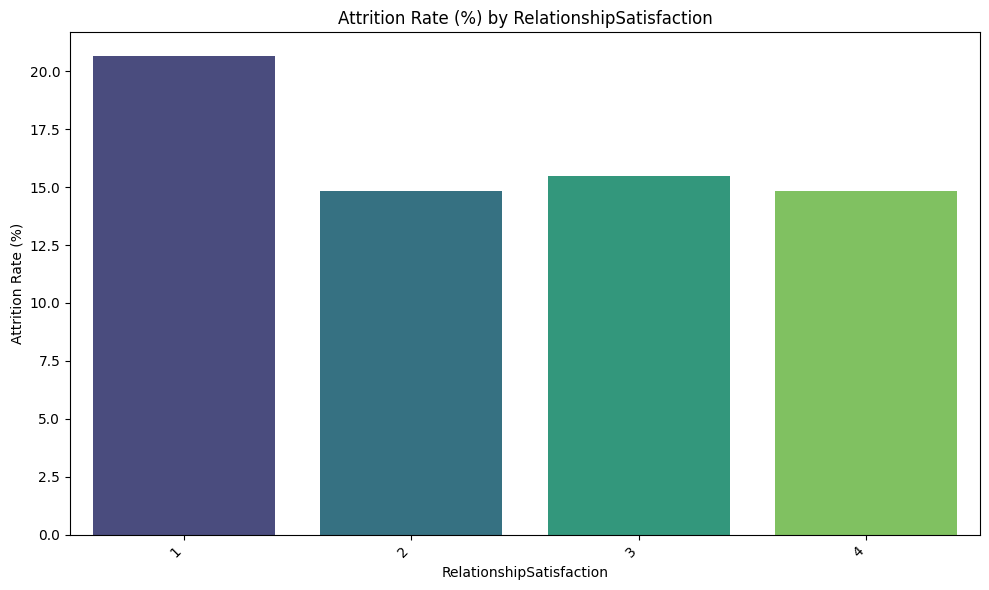

In [ ]:
plot_distribution_and_describe(df, 'RelationshipSatisfaction')
# df = create_grouped_column(df, 'PercentSalaryHike', 3, new_column_prefix='SalaryHikePercent')
plot_attrition_by_group(df,'RelationshipSatisfaction')

--- Analysis for column: StockOptionLevel ---

Descriptive Statistics:


,StockOptionLevel
count,1470.000000
mean,0.793878
std,0.852077
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,3.000000



Correlation with Attrition (Yes=1, No=0): -0.1371


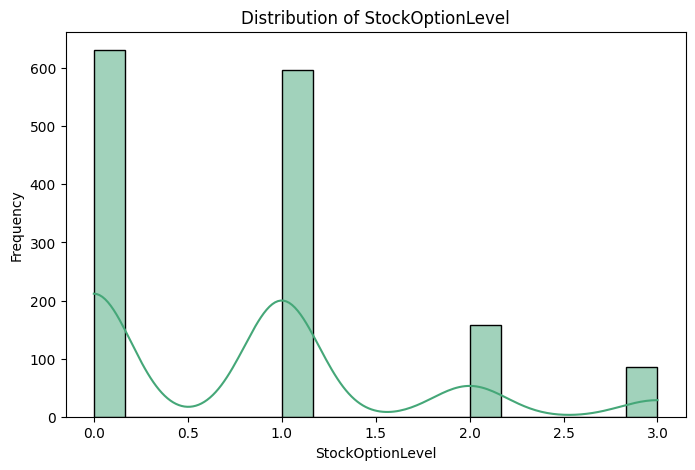

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


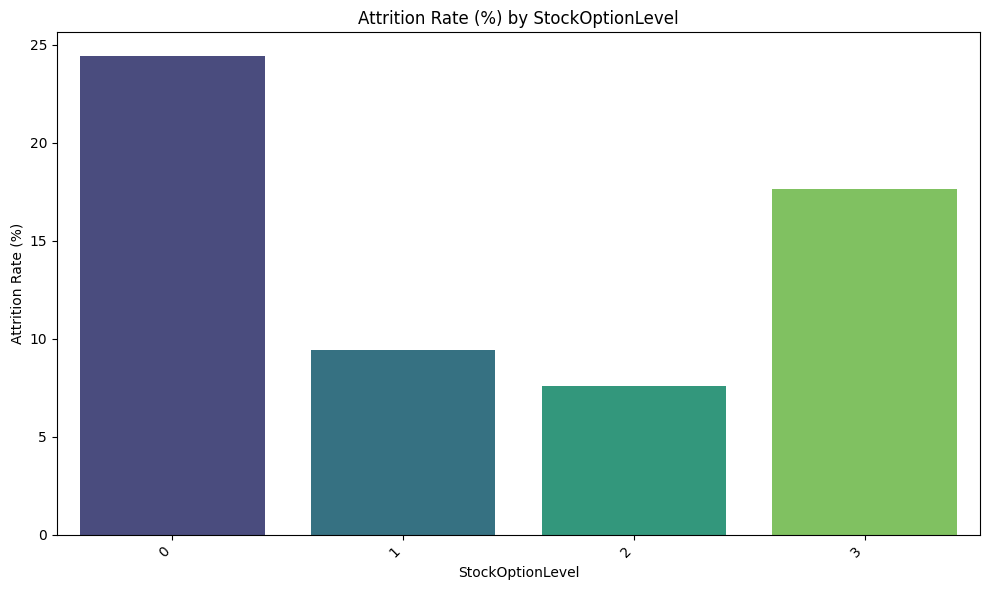

In [ ]:
plot_distribution_and_describe(df, 'StockOptionLevel')
plot_attrition_by_group(df,'StockOptionLevel')

--- Analysis for column: TotalWorkingYears ---

Descriptive Statistics:


,TotalWorkingYears
count,1470.000000
mean,11.279592
std,7.780782
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,40.000000



Correlation with Attrition (Yes=1, No=0): -0.1711


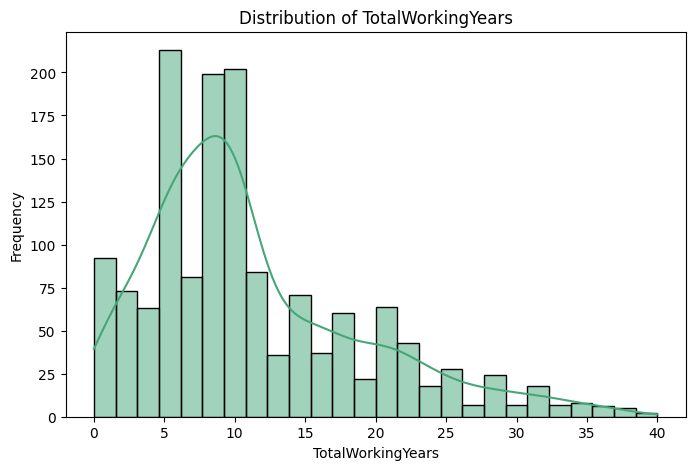

New column 'TotalWorkingYearGroups' created with 4 groups based on 'TotalWorkingYears'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


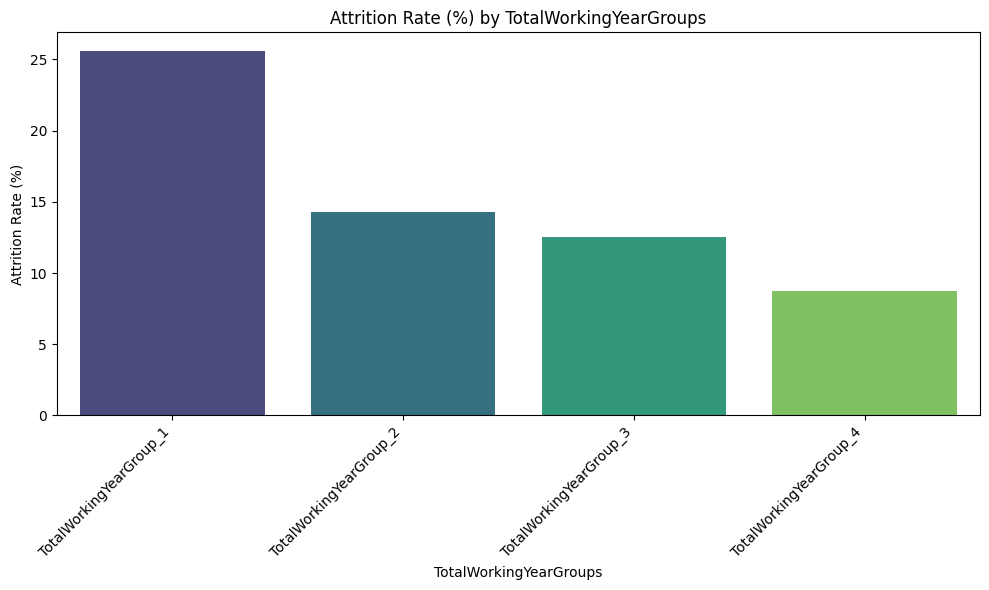

In [ ]:
plot_distribution_and_describe(df, 'TotalWorkingYears')
df = create_grouped_column(df, 'TotalWorkingYears', 4, new_column_prefix='TotalWorkingYearGroup')
plot_attrition_by_group(df,'TotalWorkingYearGroups')

--- Analysis for column: TrainingTimesLastYear ---

Descriptive Statistics:


,TrainingTimesLastYear
count,1470.000000
mean,2.799320
std,1.289271
min,0.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,6.000000



Correlation with Attrition (Yes=1, No=0): -0.0595


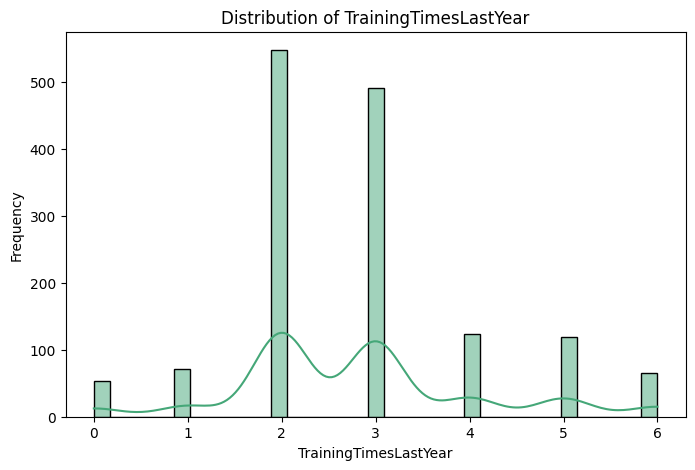

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


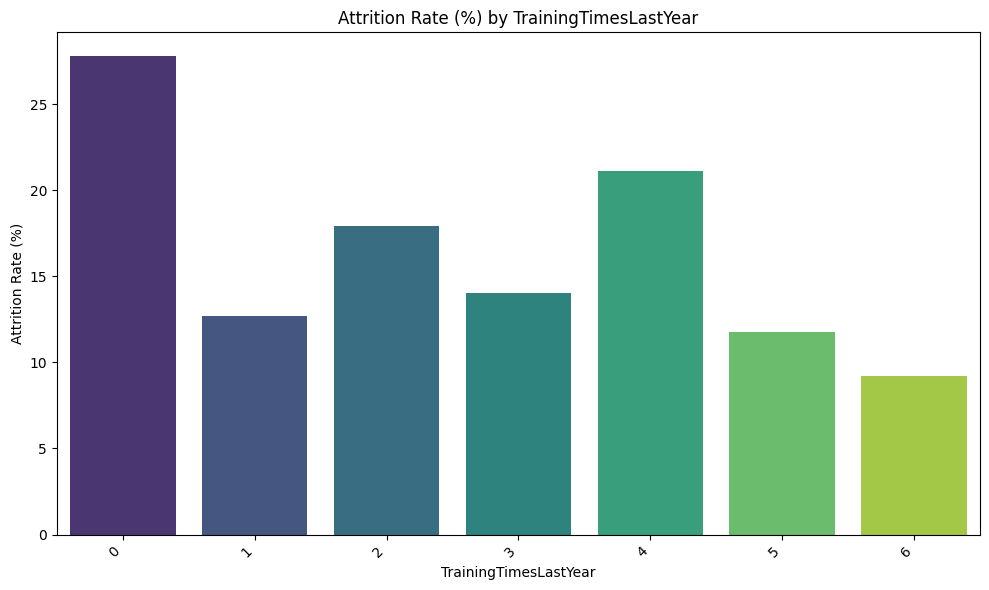

In [ ]:
plot_distribution_and_describe(df, 'TrainingTimesLastYear')
# df = create_grouped_column(df, 'TotalWorkingYears', 4, new_column_prefix='TotalWorkingYearGroup')
plot_attrition_by_group(df,'TrainingTimesLastYear')

--- Analysis for column: WorkLifeBalance ---

Descriptive Statistics:


,WorkLifeBalance
count,1470.000000
mean,2.761224
std,0.706476
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): -0.0639


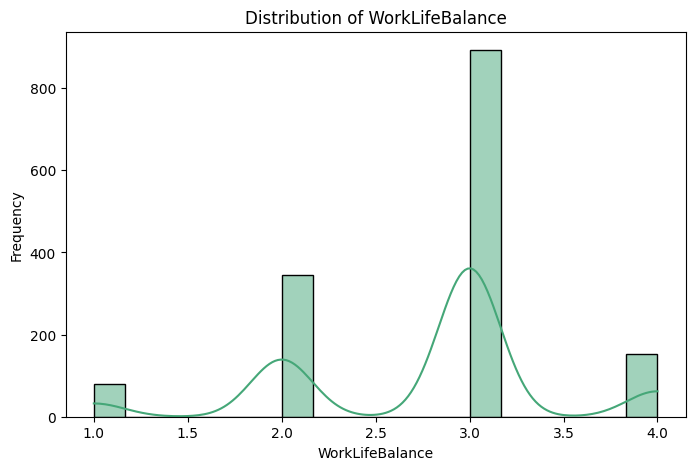

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


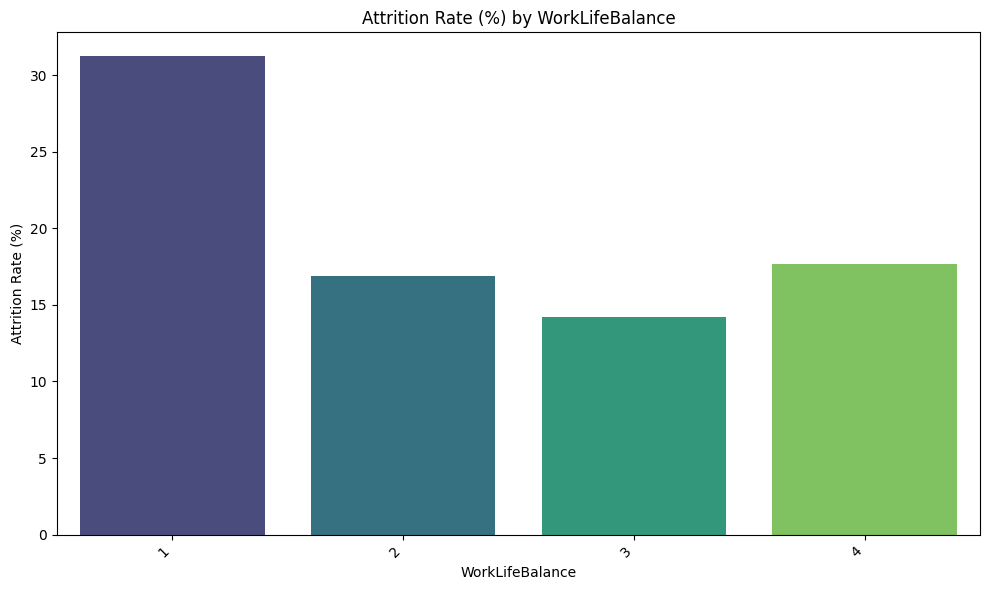

In [ ]:
plot_distribution_and_describe(df, 'WorkLifeBalance')
# df = create_grouped_column(df, 'TotalWorkingYears', 4, new_column_prefix='TotalWorkingYearGroup')
plot_attrition_by_group(df,'WorkLifeBalance')

--- Analysis for column: YearsAtCompany ---

Descriptive Statistics:


,YearsAtCompany
count,1470.000000
mean,7.008163
std,6.126525
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,40.000000



Correlation with Attrition (Yes=1, No=0): -0.1344


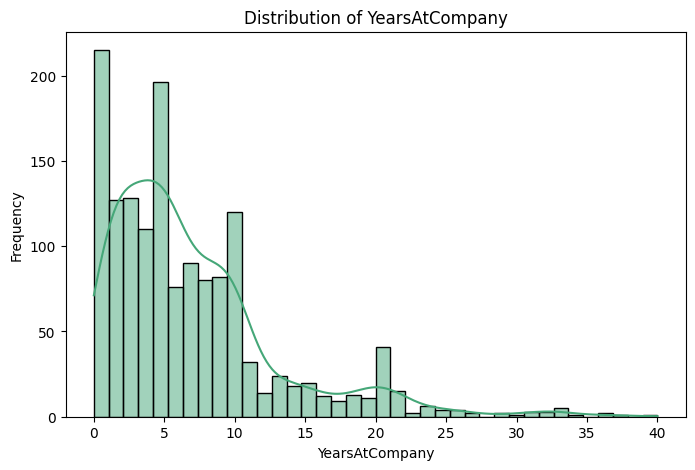

In [ ]:
plot_distribution_and_describe(df, 'YearsAtCompany')

New column 'YearsGroups' created with 4 groups based on 'YearsAtCompany'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


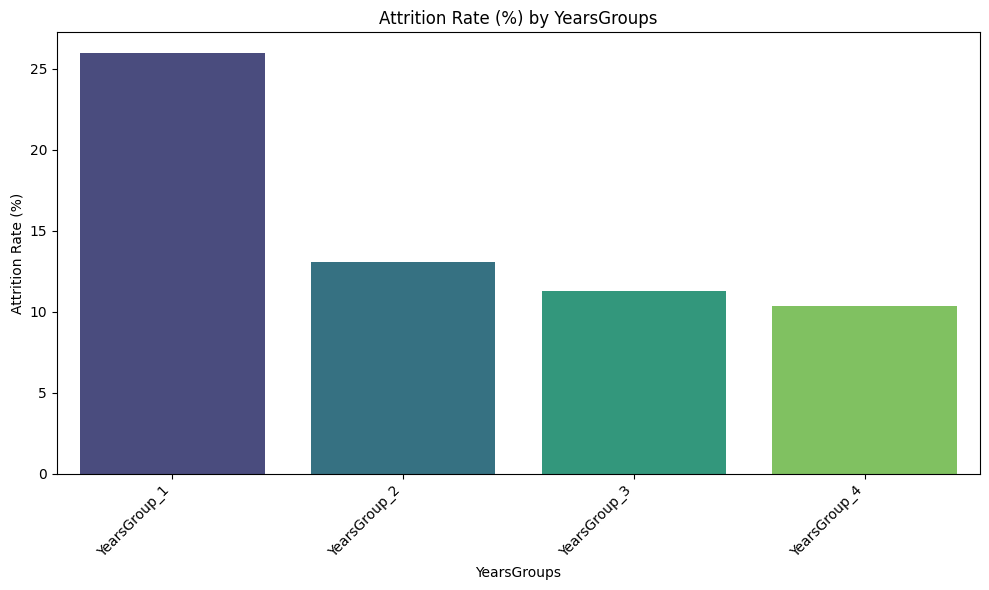

In [ ]:
df = create_grouped_column(df, 'YearsAtCompany', 4, new_column_prefix='YearsGroup')
plot_attrition_by_group(df,'YearsGroups')

--- Analysis for column: YearsInCurrentRole ---

Descriptive Statistics:


,YearsInCurrentRole
count,1470.000000
mean,4.229252
std,3.623137
min,0.000000
25%,2.000000
50%,3.000000
75%,7.000000
max,18.000000



Correlation with Attrition (Yes=1, No=0): -0.1605


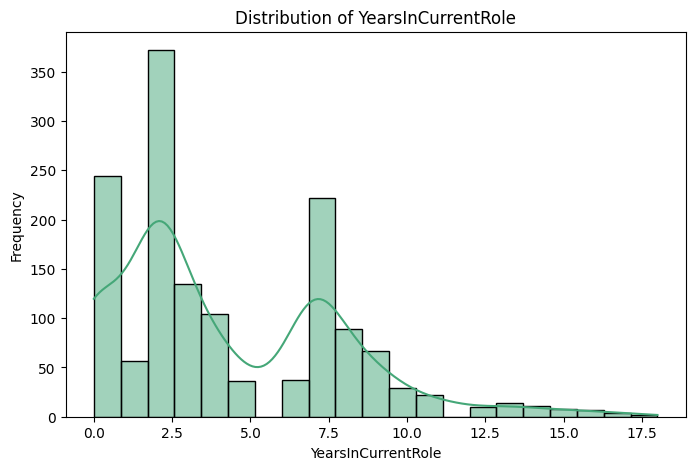

In [ ]:
plot_distribution_and_describe(df, 'YearsInCurrentRole')

New column 'YearsRoleGroups' created with 3 groups based on 'YearsInCurrentRole'.


/tmp/ipython-input-3025145433.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rates = dataframe.groupby(group_column)['Attrition'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


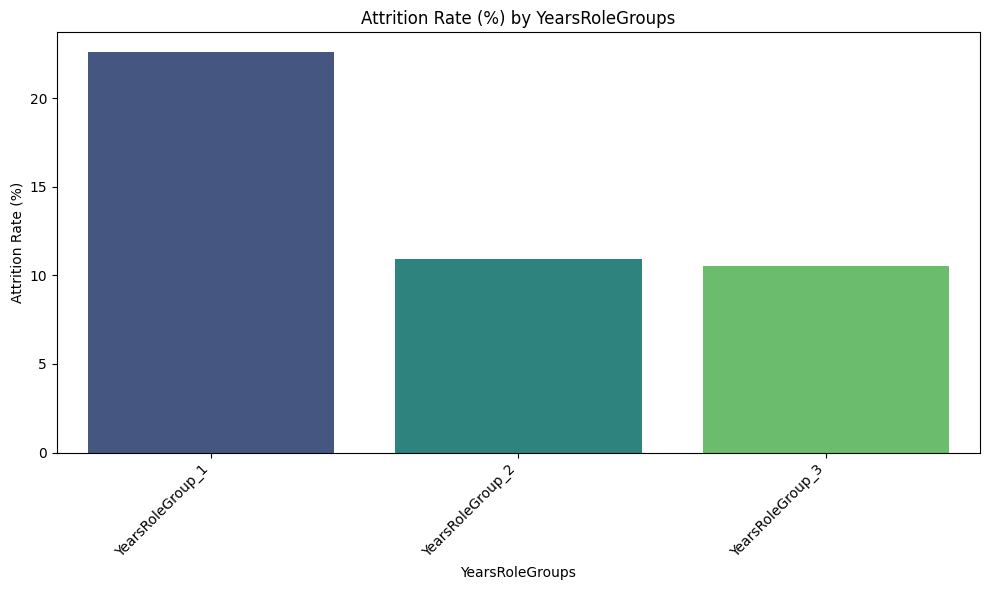

In [ ]:
df = create_grouped_column(df, 'YearsInCurrentRole', 3, new_column_prefix='YearsRoleGroup')
plot_attrition_by_group(df,'YearsRoleGroups')

--- Analysis for column: YearsSinceLastPromotion ---

Descriptive Statistics:


,YearsSinceLastPromotion
count,1470.000000
mean,2.187755
std,3.222430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,15.000000



Correlation with Attrition (Yes=1, No=0): -0.0330


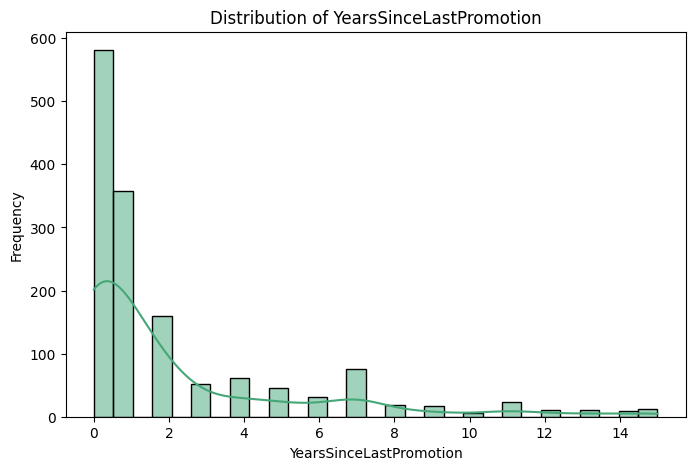

In [ ]:
plot_distribution_and_describe(df, 'YearsSinceLastPromotion')

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


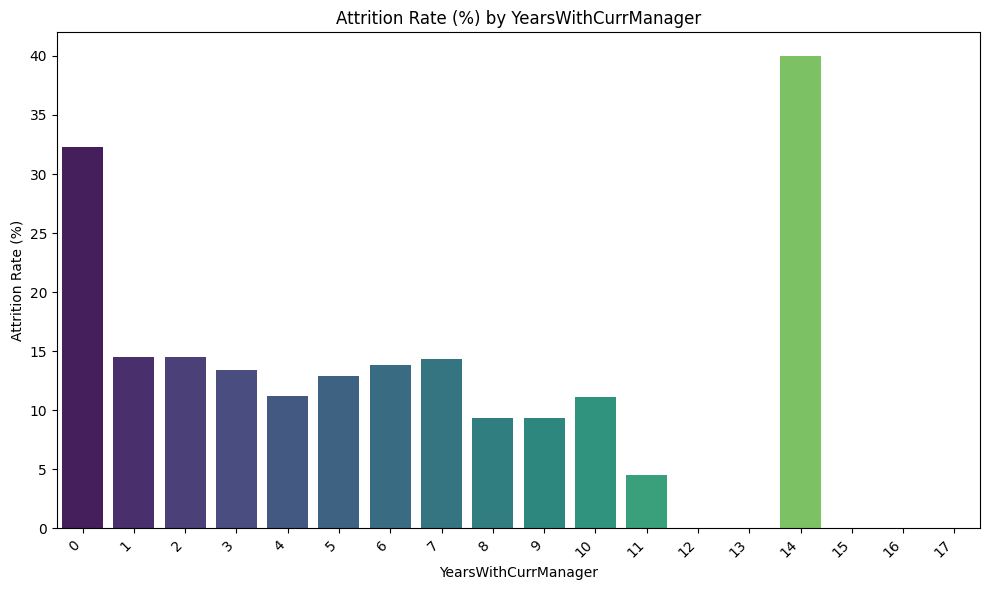

In [ ]:
# df = create_grouped_column(df, 'YearsSinceLastPromotion', 4, new_column_prefix='SinceLastPromotionYear')
plot_attrition_by_group(df,'YearsWithCurrManager')

--- Analysis for column: JobInvolvement ---

Descriptive Statistics:


,JobInvolvement
count,446.000000
mean,2.701794
std,0.705259
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000



Correlation with Attrition (Yes=1, No=0): -0.1696


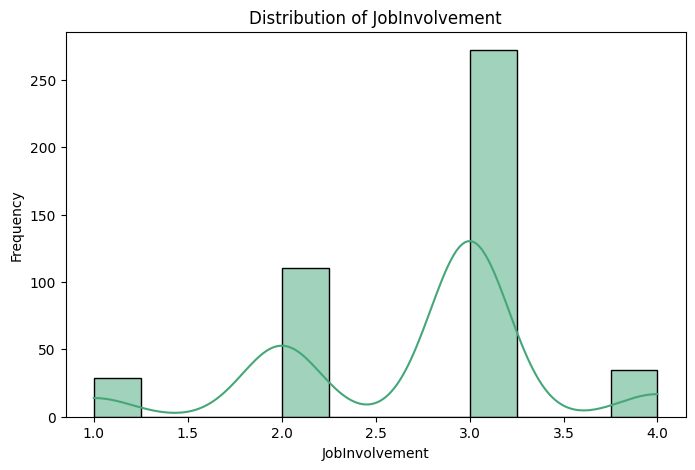

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


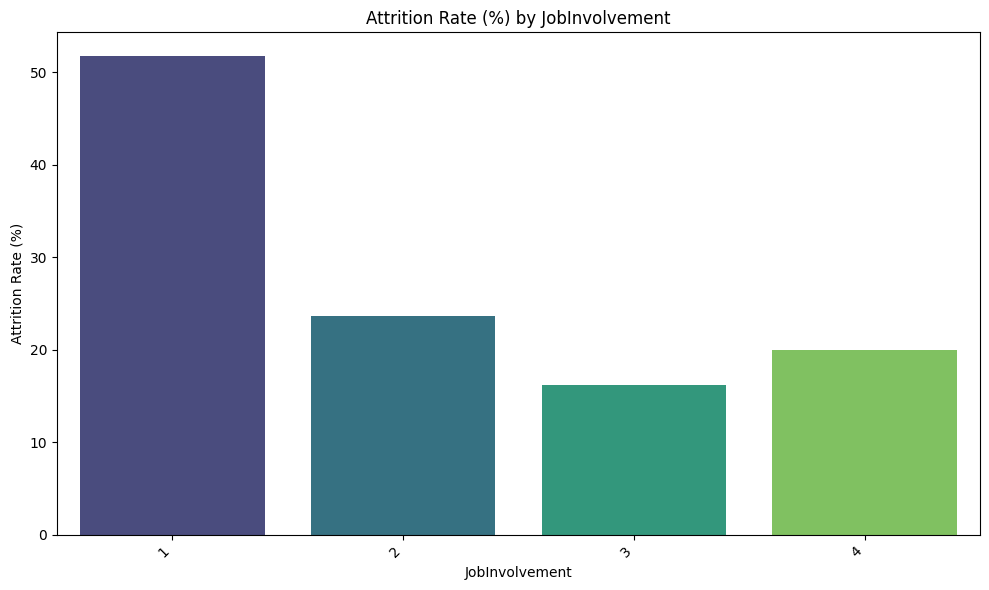

--- Analysis for column: MaritalStatus ---

Descriptive Statistics:


,MaritalStatus
count,446
unique,3
top,Married
freq,206



Correlation with Attrition is not directly applicable for categorical columns.


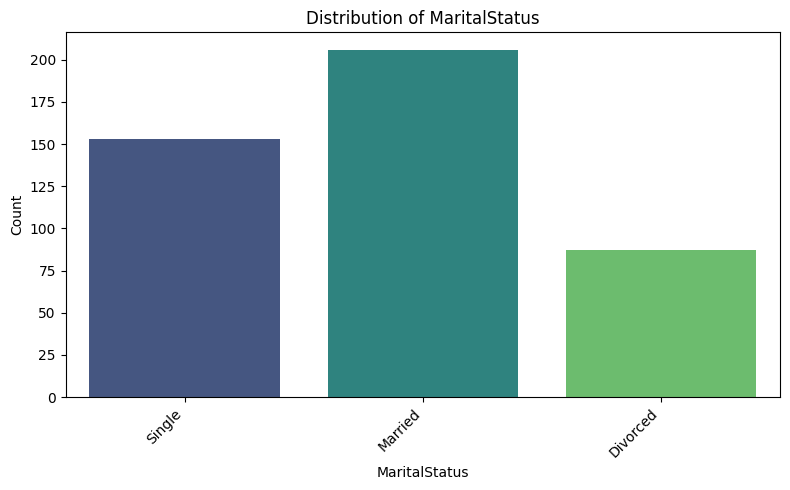

/tmp/ipython-input-3025145433.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_column, y='Attrition_Yes_Ratio', data=attrition_rates, palette='viridis')


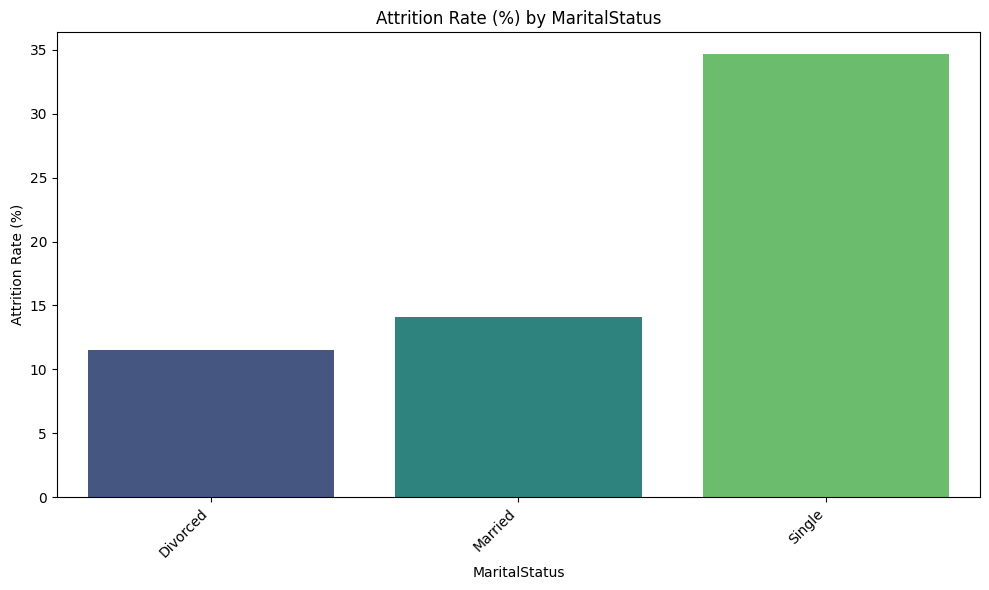

--- Analysis for column: MonthlyIncome ---

Descriptive Statistics:


,MonthlyIncome
count,446.000000
mean,6959.172646
std,4058.739322
min,1052.000000
25%,4446.250000
50%,5754.500000
75%,8776.750000
max,19847.000000



Correlation with Attrition (Yes=1, No=0): -0.1321


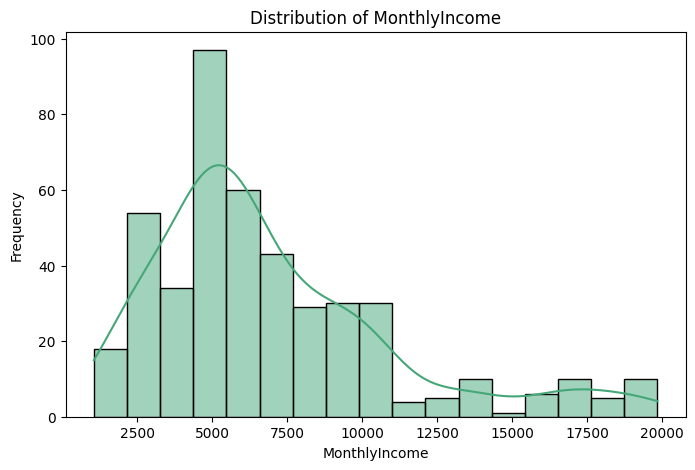

Error: Group column 'IncomeGroups' not found in the DataFrame.


In [ ]:
plot_distribution_and_describe(df_sales, 'JobInvolvement')
plot_attrition_by_group(df_sales,'JobInvolvement')

plot_distribution_and_describe(df_sales, 'MaritalStatus')
plot_attrition_by_group(df_sales,'MaritalStatus')

plot_distribution_and_describe(df_sales, 'MonthlyIncome')
plot_attrition_by_group(df_sales,'IncomeGroups')

/tmp/ipython-input-797437822.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rate_by_age_stockoption = df.groupby(['Ages', 'StockOptionLevel'])['Attrition_Numeric'].mean().reset_index()


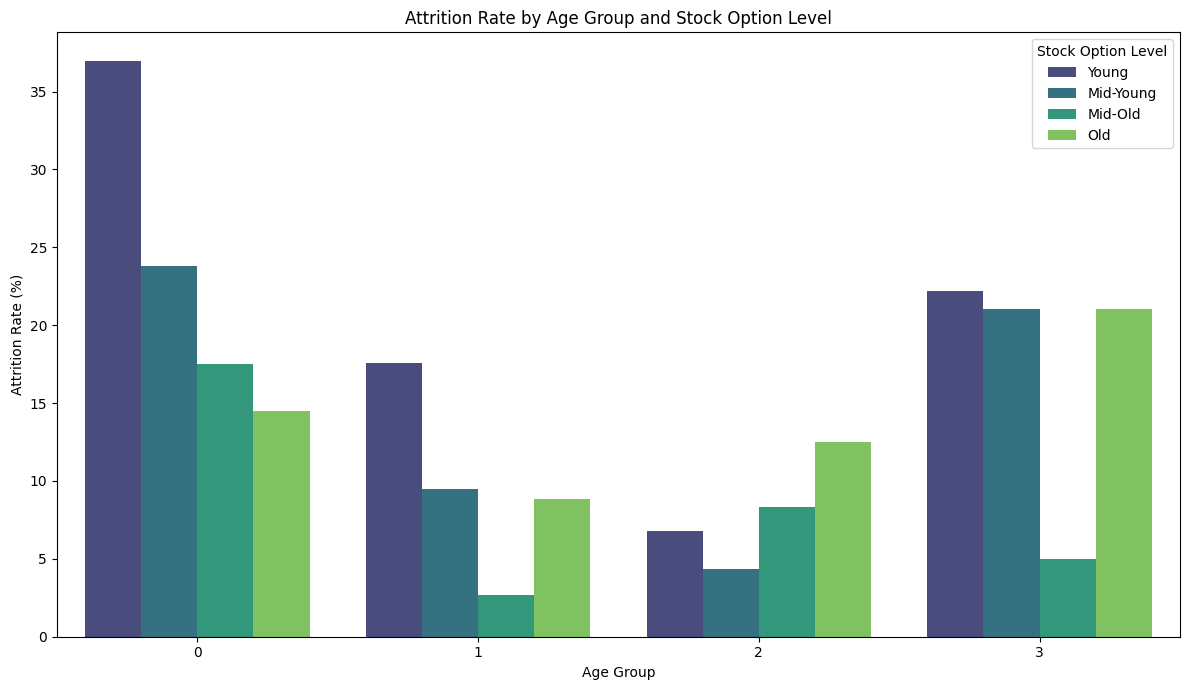

In [ ]:
# Ensure Attrition_Numeric exists (already created in df_heatmap, but good to have for df if running standalone)
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate attrition rates by Ages and StockOptionLevel
attrition_rate_by_age_stockoption = df.groupby(['Ages', 'StockOptionLevel'])['Attrition_Numeric'].mean().reset_index()
attrition_rate_by_age_stockoption['Attrition_Rate_Percent'] = attrition_rate_by_age_stockoption['Attrition_Numeric'] * 100

plt.figure(figsize=(12, 7))
sns.barplot(x='StockOptionLevel', y='Attrition_Rate_Percent', hue='Ages', data=attrition_rate_by_age_stockoption, palette='viridis')
plt.title('Attrition Rate by Age Group and Stock Option Level')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.legend(title='Stock Option Level')
plt.tight_layout()
plt.show()

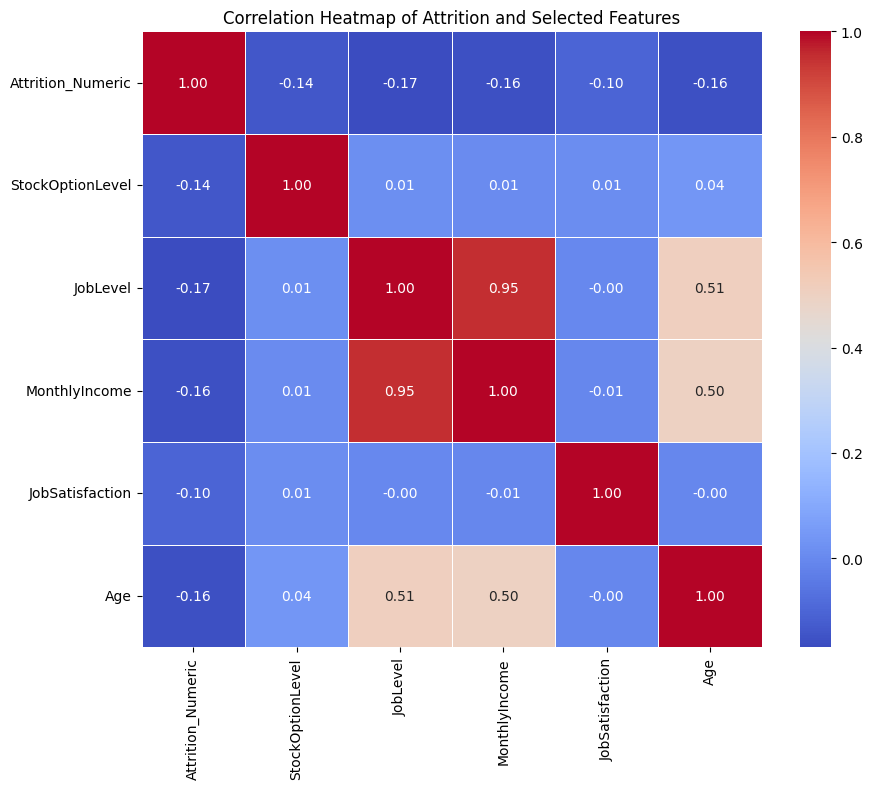

In [ ]:
# Ensure 'Attrition_Numeric' is available, converting 'Attrition' if not already done
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Define the columns for the new heatmap
heatmap_columns = [
    'Attrition_Numeric',
    'StockOptionLevel',
    'JobLevel',
    'MonthlyIncome',
    'JobSatisfaction',
    'Age'
]

# Calculate the correlation matrix for the selected columns
correlation_matrix_selected = df[heatmap_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Attrition and Selected Features')
plt.show()


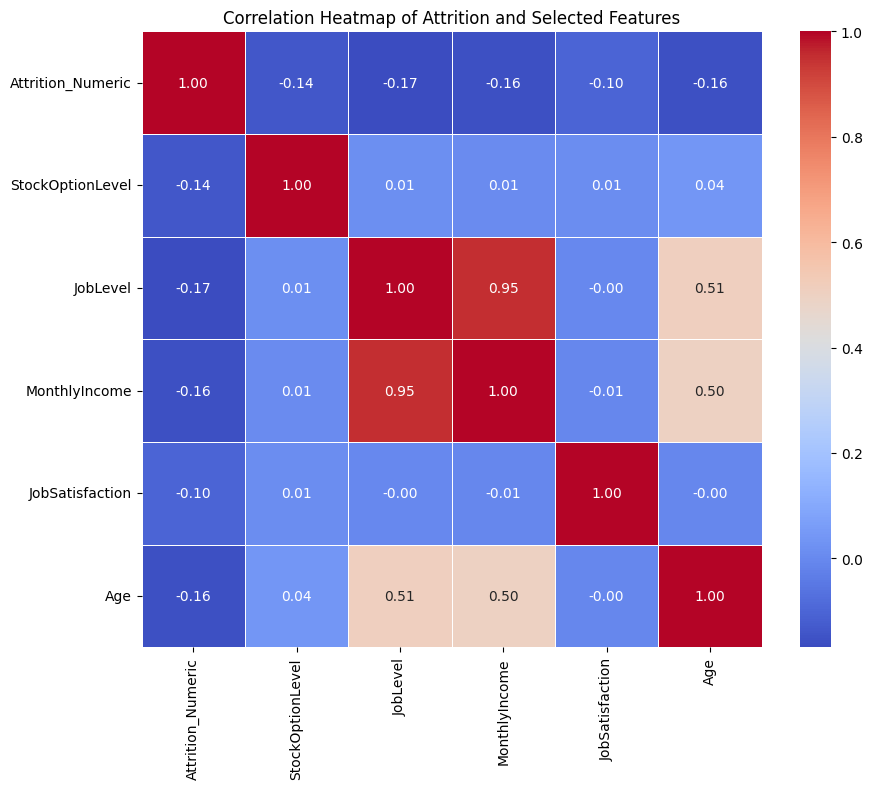

In [ ]:
# Ensure 'Attrition_Numeric' is available, converting 'Attrition' if not already done
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Define the columns for the new heatmap
heatmap_columns = [
    'Attrition_Numeric',
    'StockOptionLevel',
    'JobLevel',
    'MonthlyIncome',
    'JobSatisfaction',
    'Age'
]

# Calculate the correlation matrix for the selected columns
correlation_matrix_selected = df[heatmap_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Attrition and Selected Features')
plt.show()

In [ ]:
# Create df_non_sales (employees not in the Sales department)
df_non_sales = df[df['Department'] != 'Sales']

# Create df_sales_rep (employees with the 'Sales Representative' JobRole)
df_sales = df[df['JobRole'] == 'Sales Representative']

print(f"df_non_sales created with {len(df_non_sales)} rows.")
print(f"df_sales_rep created with {len(df_sales)} rows.")
display(df_non_sales.head())
display(df_sales.head())

df_non_sales created with 1024 rows.
df_sales_rep created with 83 rows.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Ages,Incomes,SalaryHikePercents,TotalWorkingYearGroups,YearsGroups,YearsRoleGroups,Attrition_Numeric
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,7,1,7,Old,Mid-High Income,SalaryHikePercent_4,TotalWorkingYearGroup_2,YearsGroup_4,YearsRoleGroup_3,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,0,0,Mid-Old,Low Income,SalaryHikePercent_3,TotalWorkingYearGroup_2,YearsGroup_1,YearsRoleGroup_1,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,7,3,0,Mid-Young,Low Income,SalaryHikePercent_1,TotalWorkingYearGroup_2,YearsGroup_3,YearsRoleGroup_3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,2,2,2,Young,Mid-Low Income,SalaryHikePercent_1,TotalWorkingYearGroup_1,YearsGroup_1,YearsRoleGroup_1,0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,7,3,6,Mid-Young,Mid-Low Income,SalaryHikePercent_2,TotalWorkingYearGroup_2,YearsGroup_3,YearsRoleGroup_3,0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Ages,Incomes,SalaryHikePercents,TotalWorkingYearGroups,YearsGroups,YearsRoleGroups,Attrition_Numeric
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,1,27,...,3,0,3,Mid-Young,Mid-Low Income,SalaryHikePercent_4,TotalWorkingYearGroup_2,YearsGroup_2,YearsRoleGroup_2,1
33,39,Yes,Travel_Rarely,895,Sales,5,3,Technical Degree,1,42,...,0,0,0,Mid-Old,Low Income,SalaryHikePercent_2,TotalWorkingYearGroup_4,YearsGroup_1,YearsRoleGroup_1,1
36,50,Yes,Travel_Rarely,869,Sales,3,2,Marketing,1,47,...,2,0,2,Old,Low Income,SalaryHikePercent_2,TotalWorkingYearGroup_1,YearsGroup_1,YearsRoleGroup_1,1
37,35,No,Travel_Rarely,890,Sales,2,3,Marketing,1,49,...,2,2,2,Mid-Young,Low Income,SalaryHikePercent_2,TotalWorkingYearGroup_1,YearsGroup_1,YearsRoleGroup_1,0
86,23,No,Travel_Rarely,541,Sales,2,1,Technical Degree,1,113,...,0,0,0,Young,Low Income,SalaryHikePercent_2,TotalWorkingYearGroup_1,YearsGroup_1,YearsRoleGroup_1,0


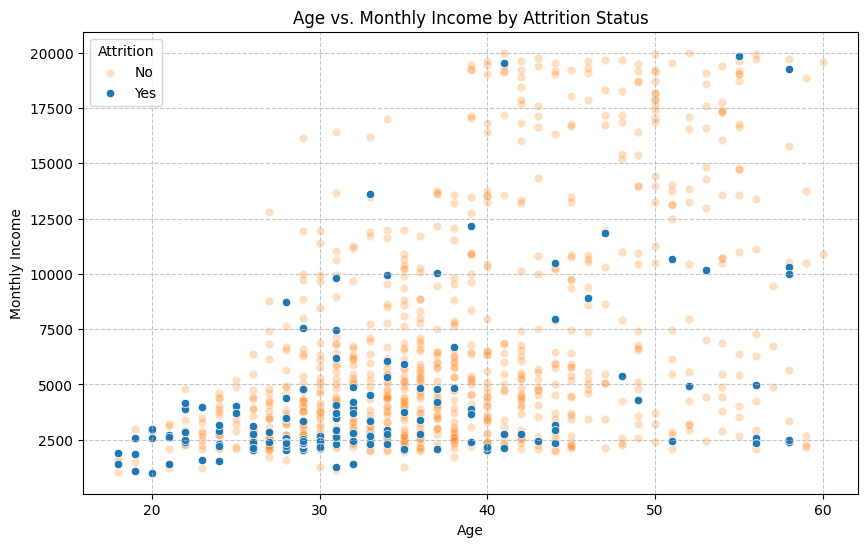

In [ ]:
plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes

# Plot 'Attrition' == 'No' with lower alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df_non_sales[df_non_sales['Attrition'] == 'No'],
                color='#ff7f0e', alpha=0.25, label='No', ax=ax)

# Plot 'Attrition' == 'Yes' with default alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df_non_sales[df_non_sales['Attrition'] == 'Yes'],
                color='#1f77b4', alpha=1, label='Yes', ax=ax)

plt.title('Age vs. Monthly Income by Attrition Status')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend(title='Attrition')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

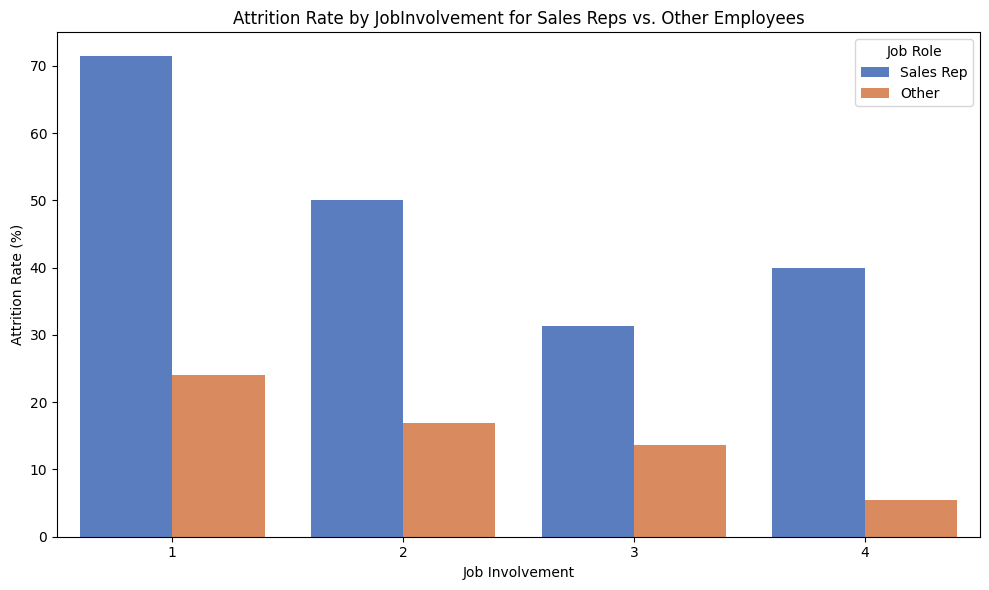

In [ ]:
# Calculate attrition rates for sales employees by JobInvolvement
sales_attrition_rates = df_sales.groupby('JobInvolvement')['Attrition'].value_counts(normalize=True).unstack()
sales_attrition_rates['Attrition_Yes_Ratio'] = sales_attrition_rates.get('Yes', 0) * 100
sales_attrition_rates = sales_attrition_rates[['Attrition_Yes_Ratio']].reset_index()
sales_attrition_rates['JobRole'] = 'Sales Rep'

# Calculate attrition rates for non-sales employees by JobInvolvement
non_sales_attrition_rates = df_non_sales.groupby('JobInvolvement')['Attrition'].value_counts(normalize=True).unstack()
non_sales_attrition_rates['Attrition_Yes_Ratio'] = non_sales_attrition_rates.get('Yes', 0) * 100
non_sales_attrition_rates = non_sales_attrition_rates[['Attrition_Yes_Ratio']].reset_index()
non_sales_attrition_rates['JobRole'] = 'Other'

# Combine the dataframes
combined_attrition_rates = pd.concat([sales_attrition_rates, non_sales_attrition_rates])

plt.figure(figsize=(10, 6))
sns.barplot(x='JobInvolvement', y='Attrition_Yes_Ratio', hue='JobRole', data=combined_attrition_rates, palette='muted')
plt.title('Attrition Rate by JobInvolvement for Sales Reps vs. Other Employees')
plt.xlabel('Job Involvement')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Job Role')
plt.tight_layout()
plt.show()

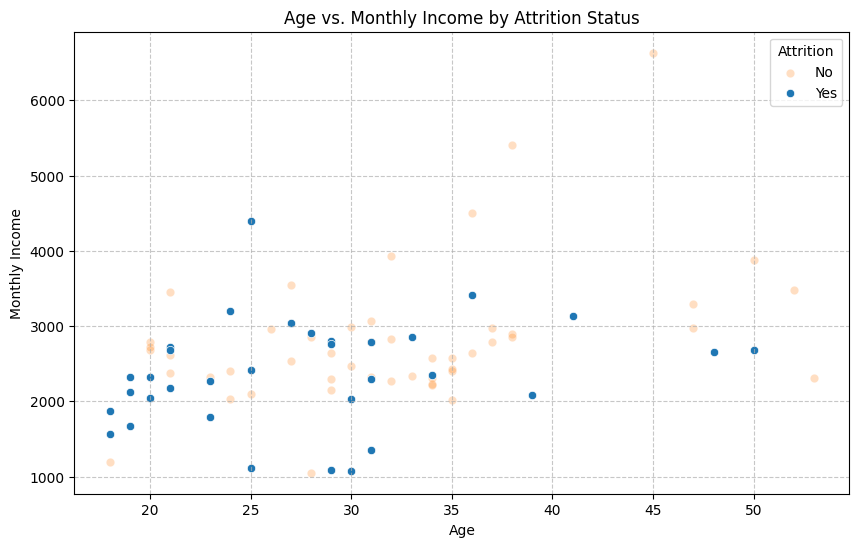

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes

# Plot 'Attrition' == 'No' with lower alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df_sales[df_sales['Attrition'] == 'No'],
                color='#ff7f0e', alpha=0.25, label='No', ax=ax)

# Plot 'Attrition' == 'Yes' with default alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df_sales[df_sales['Attrition'] == 'Yes'],
                color='#1f77b4', alpha=1, label='Yes', ax=ax)

plt.title('Age vs. Monthly Income by Attrition Status')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend(title='Attrition')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
"EmployeeCount", "EmployeeNumber", "StandardHours", "Over18", "PerformanceRating"

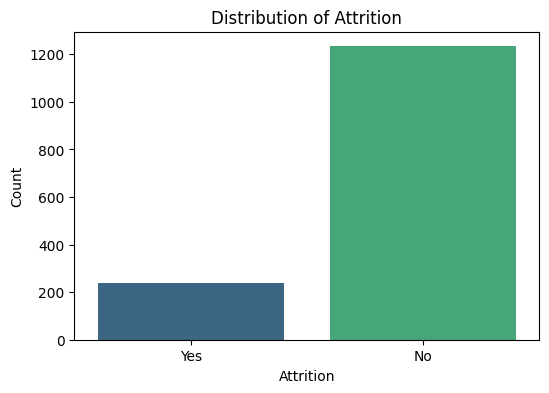

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, hue='Attrition', palette='viridis', legend=False)
plt.title('Distribution of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

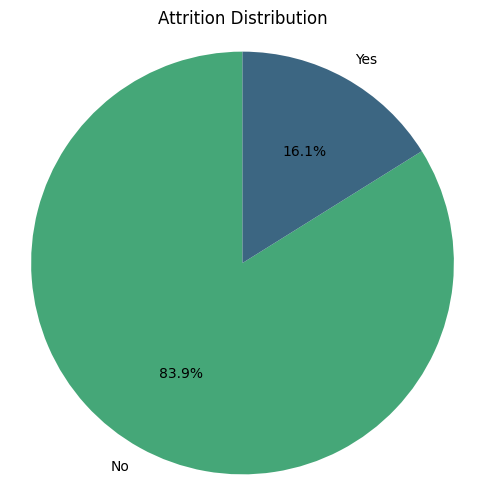

In [ ]:
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%', startangle=90, colors=['#45a778', '#3c6682'])
plt.title('Attrition Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
column_categories = {
    'Employee Demographics & Tenure': ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole'],
    'Job Related Perceptions': ['JobInvolvement', 'JobSatisfaction'],
    'Compensation & Benefits': ['JobLevel', 'MonthlyIncome', 'StockOptionLevel']
}

print("Column categories dictionary created successfully:")
print(column_categories)

Column categories dictionary created successfully:
{'Employee Demographics & Tenure': ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole'], 'Job Related Perceptions': ['JobInvolvement', 'JobSatisfaction'], 'Compensation & Benefits': ['JobLevel', 'MonthlyIncome', 'StockOptionLevel']}


In [ ]:
df_heatmap = df.copy()
# Convert 'Attrition' to numerical (Yes=1, No=0)
df_heatmap['Attrition_Numeric'] = df_heatmap['Attrition'].map({'Yes': 1, 'No': 0})

# Get all columns from the categories dictionary
selected_columns = []
for category in column_categories.values():
    selected_columns.extend(category)

# Add the numerical Attrition column to the list of selected columns
selected_columns.append('Attrition_Numeric')

print(f"Selected columns for heatmap: {selected_columns}")

Selected columns for heatmap: ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'JobInvolvement', 'JobSatisfaction', 'JobLevel', 'MonthlyIncome', 'StockOptionLevel', 'Attrition_Numeric']


In [ ]:
correlation_matrix = df_heatmap[selected_columns].corr()

Correlation matrix computed successfully:
                         Age  TotalWorkingYears  YearsAtCompany  \
Age                 1.000000           0.680381        0.311309   
TotalWorkingYears   0.680381           1.000000        0.628133   
YearsAtCompany      0.311309           0.628133        1.000000   
YearsInCurrentRole  0.212901           0.460365        0.758754   
JobInvolvement      0.029820          -0.005533       -0.021355   
JobSatisfaction    -0.004892          -0.020185       -0.003803   
JobLevel            0.509604           0.782208        0.534739   
MonthlyIncome       0.497855           0.772893        0.514285   
StockOptionLevel    0.037510           0.010136        0.015058   
Attrition_Numeric  -0.159205          -0.171063       -0.134392   

                    YearsInCurrentRole  JobInvolvement  JobSatisfaction  \
Age                           0.212901        0.029820        -0.004892   
TotalWorkingYears             0.460365       -0.005533        -0.02018

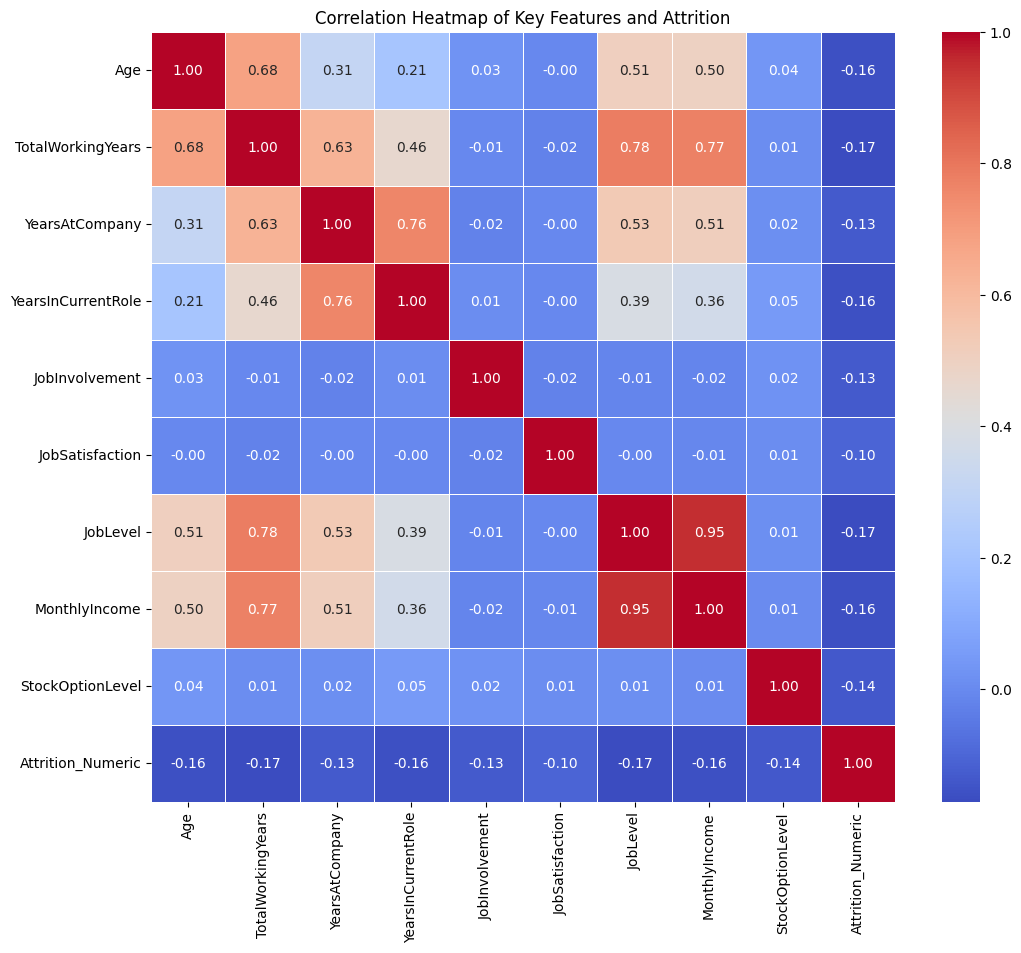

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Features and Attrition')
plt.show()

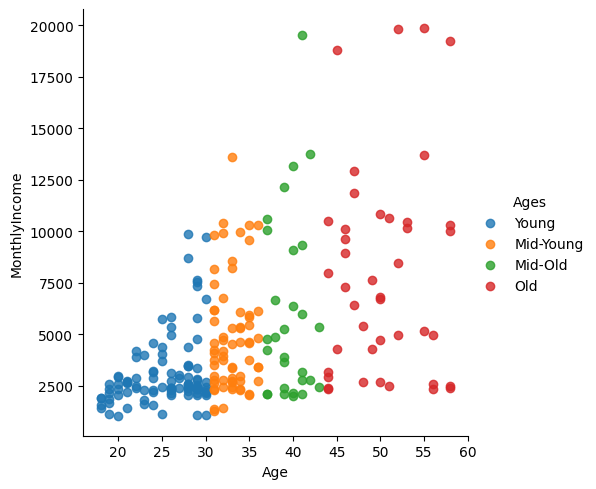

In [ ]:
sns.lmplot(x="Age",y="MonthlyIncome",data=df[df['Attrition'] == 'Yes'], hue='Ages', fit_reg=False)

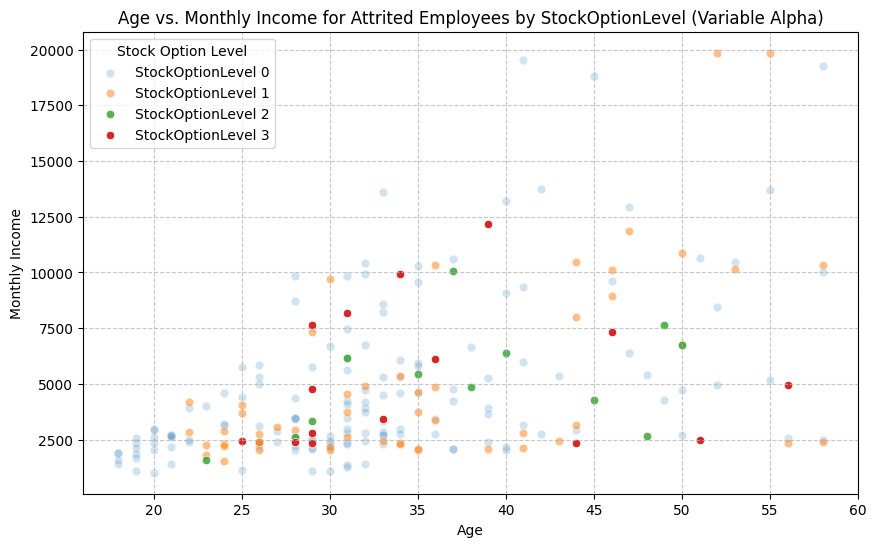

In [ ]:

df['IncomeGroups'] = pd.qcut(df['MonthlyIncome'],q=4,labels=['Low Income','Mid-Low Income','Mid-High Income','High Income'])

plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes to plot on

# Filter data for Attrition == 'Yes' once
df_attrition_yes = df[df['Attrition'] == 'Yes']

# Define custom alphas for each StockOptionLevel
# You can customize these values as needed (0.0 is fully transparent, 1.0 is fully opaque)
alpha_settings = {
    0: 0.2, # For StockOptionLevel 0, make it less visible
    1: 0.5, # For StockOptionLevel 1, make it moderately visible
    2: 0.8, # For StockOptionLevel 2, make it more visible
    3: 1.0  # For StockOptionLevel 3, make it fully visible
}

# Get unique StockOptionLevels present in the filtered data to ensure no errors from missing levels
unique_stock_options = sorted(df_attrition_yes['StockOptionLevel'].unique())

# Iterate through each unique StockOptionLevel and plot with its specific alpha
for level in unique_stock_options:
    subset = df_attrition_yes[df_attrition_yes['StockOptionLevel'] == level]
    # Get alpha from settings, or use a default if level not explicitly defined
    current_alpha = alpha_settings.get(level, 0.7)

    sns.scatterplot(
        x="Age",
        y="MonthlyIncome",
        data=subset,
        label=f'StockOptionLevel {level}',
        alpha=current_alpha,
        ax=ax # Plot on the same axes
    )

plt.title('Age vs. Monthly Income for Attrited Employees by StockOptionLevel (Variable Alpha)')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend(title='Stock Option Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


<Axes: xlabel='Age', ylabel='MonthlyIncome'>

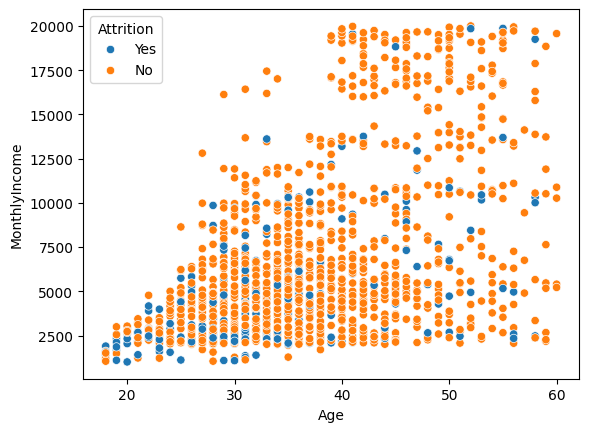

In [ ]:
sns.scatterplot(x="Age",y="MonthlyIncome",data=df, hue='Attrition')



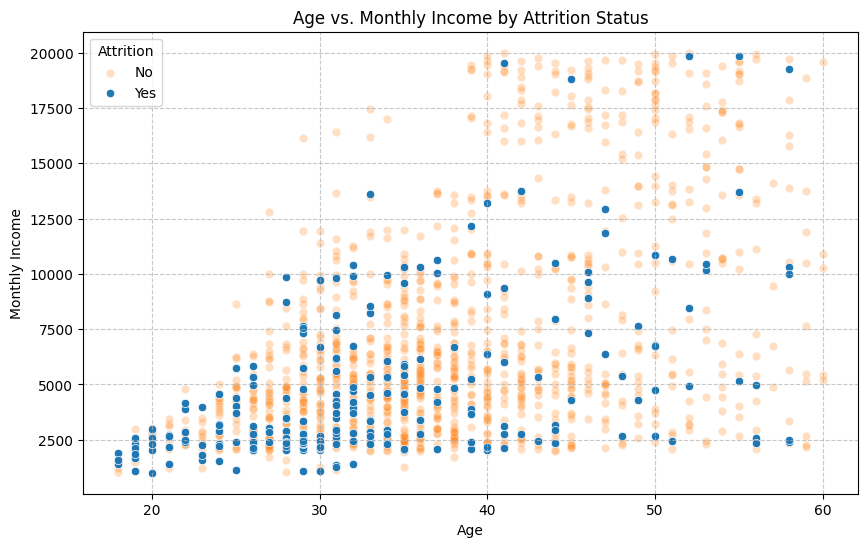

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes

# Plot 'Attrition' == 'No' with lower alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df[df['Attrition'] == 'No'],
                color='#ff7f0e', alpha=0.25, label='No', ax=ax)

# Plot 'Attrition' == 'Yes' with default alpha
sns.scatterplot(x="Age", y="MonthlyIncome", data=df[df['Attrition'] == 'Yes'],
                color='#1f77b4', alpha=1, label='Yes', ax=ax)

plt.title('Age vs. Monthly Income by Attrition Status')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend(title='Attrition')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

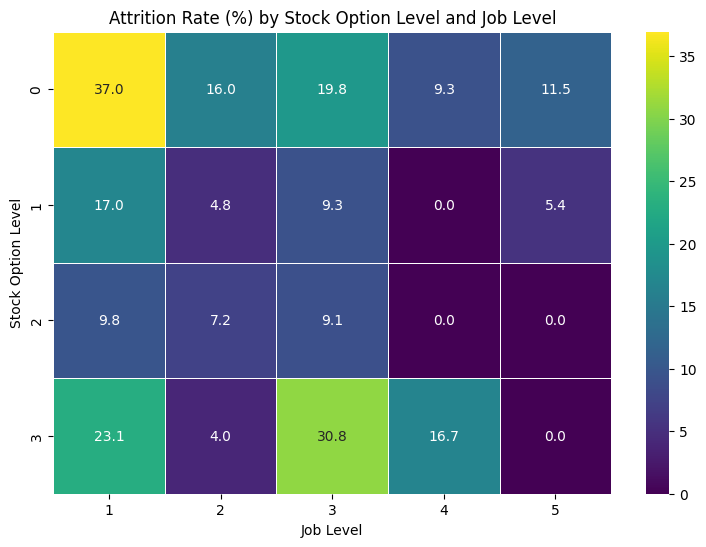

In [ ]:
# Ensure 'Attrition_Numeric' is available
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate the mean attrition rate for each combination of StockOptionLevel and JobLevel
attrition_rate_pivot = df.pivot_table(values='Attrition_Numeric', index='StockOptionLevel', columns='JobLevel', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(attrition_rate_pivot * 100, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Attrition Rate (%) by Stock Option Level and Job Level')
plt.xlabel('Job Level')
plt.ylabel('Stock Option Level')
plt.show()


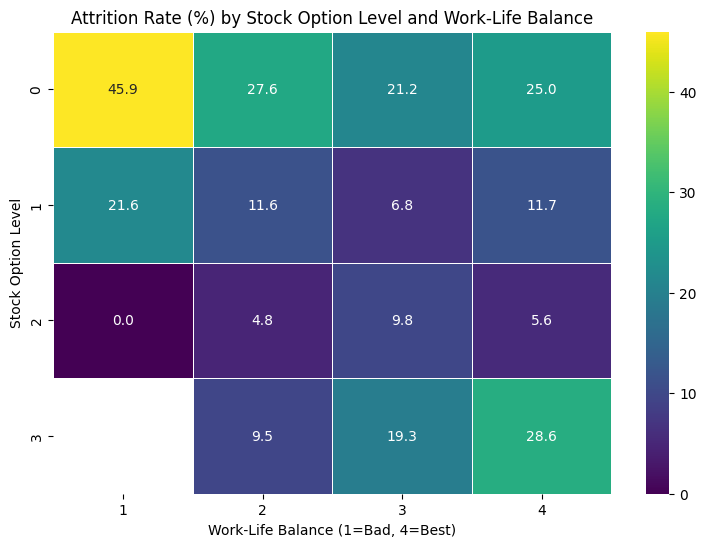

In [ ]:
# Ensure 'Attrition_Numeric' is available
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate the mean attrition rate for each combination of StockOptionLevel and WorkLifeBalance
attrition_rate_pivot = df.pivot_table(values='Attrition_Numeric', index='StockOptionLevel', columns='WorkLifeBalance', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(attrition_rate_pivot * 100, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Attrition Rate (%) by Stock Option Level and Work-Life Balance')
plt.xlabel('Work-Life Balance (1=Bad, 4=Best)')
plt.ylabel('Stock Option Level')
plt.show()


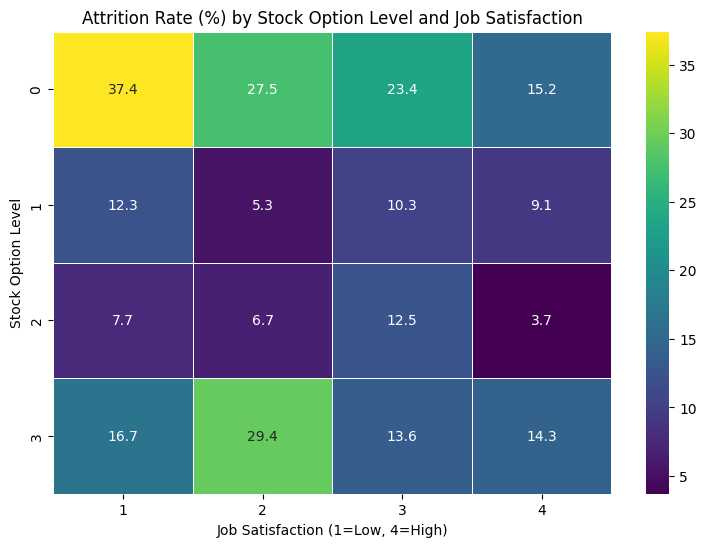

In [ ]:
# Ensure 'Attrition_Numeric' is available
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate the mean attrition rate for each combination of StockOptionLevel and JobSatisfaction
attrition_rate_pivot = df.pivot_table(values='Attrition_Numeric', index='StockOptionLevel', columns='JobSatisfaction', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(attrition_rate_pivot * 100, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Attrition Rate (%) by Stock Option Level and Job Satisfaction')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Stock Option Level')
plt.show()


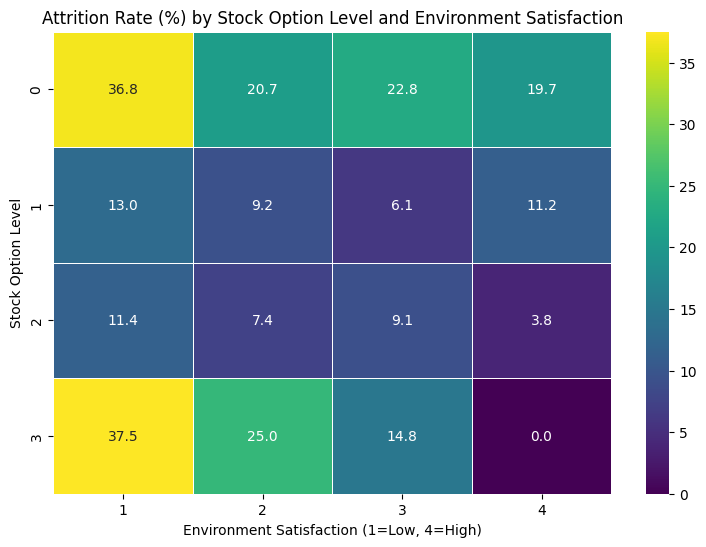

In [ ]:
# Ensure 'Attrition_Numeric' is available
if 'Attrition_Numeric' not in df.columns:
    df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate the mean attrition rate for each combination of StockOptionLevel and EnvironmentSatisfaction
attrition_rate_pivot = df.pivot_table(values='Attrition_Numeric', index='StockOptionLevel', columns='EnvironmentSatisfaction', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(attrition_rate_pivot * 100, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Attrition Rate (%) by Stock Option Level and Environment Satisfaction')
plt.xlabel('Environment Satisfaction (1=Low, 4=High)')
plt.ylabel('Stock Option Level')
plt.show()
